In [38]:
from utils.dependencies import *;
import Sampler

In [43]:
lam = 1

q_from_l(lam, 0.2, 10), q_from_l(lam, 0.65, 10)

(np.float64(0.19226746324666236), np.float64(0.12486140736240865))

In [2]:
def print_table(table, label=None, decimal_places=2):
    rates = [100] + [len(table[table["solution_type"] == soltype])/len(table)*100 for soltype in [0,5,7,9,12]]
    grid = [
        rates,
        [int(grp/100*len(table)) for grp in rates]
    ]
    row_labels = ["Rate (%)", "Counts"]
    col_labels = ["Total", "low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
    df = pd.DataFrame(grid, index=row_labels, columns=col_labels)
    displaydf = df.style.format(
        "{:.0f}",
        subset=pd.IndexSlice["Counts", :]
    ).format(
        "{:." + str(decimal_places) + "f}",
        subset=pd.IndexSlice["Rate (%)", :]
    )
    
    if label is not None:
        displaydf.set_caption(label)
    
    display(displaydf)

## Constraining $f_b$

In [4]:
mdwarfs = Table.read('./data/0306_final_catalogue.fits', format='fits')

massratios = pd.read_csv("./data/mass_ratio_threshold_table.csv", delimiter=",")
generate_q_cutoffs(mdwarfs, massratios)
indices = [0,5,7,9,12]
all_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type", "q_max"]

masses = np.array([row["mass_single"] for row in mdwarfs])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(mdwarfs):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)
all_mdwarfs = np.array(all_mdwarfs)

percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
mdwarfs["mass"] = mdwarfs["mass_single"]

  0%|          | 0/282357 [00:00<?, ?it/s]

In [5]:
def mass_binned_data(sc_cubes, catalogue, p_model=(4,2), q_model=0, model_cube_size=(15,15), scale=5):
    fb_results = []
    likelihood_sets = []

    for mass_index in tqdm(range(len(mass_lims))):
        temp_catalogue = []
        for _, obj in enumerate(catalogue):
            if mass_index == 0:
                if obj["mass"] < mass_lims[0]:
                    temp_catalogue.append(obj)
            else:
                if (mass_lims[mass_index-1] < obj["mass"]) & (obj["mass"] <= mass_lims[mass_index]):
                    temp_catalogue.append(obj)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model, q_model=q_model)
        synthsampler = Sampler.popsampler(sc_cubes, temp_catalogue, model_cube=model_cube)
        _, likelihoods = synthsampler.binarity(resolution=10000, scale=scale, verbose=False)
        fb_results.append(synthsampler.fb_estimator())
        likelihood_sets.append(likelihoods)
        print(f'{synthsampler.fb_estimator()[0]*100:.2f}')
    fb_results = np.array(fb_results)
    likelihood_sets = np.array(likelihood_sets)
    return fb_results, likelihood_sets

In [6]:
sc_cubes = pickle.load(open("./data/2026-04-03-65_mdwarfs.pkl", "rb"))
model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=0)
synth_results, likelihood_sets = mass_binned_data(sc_cubes, all_mdwarfs, p_model=(4,1.3), q_model=0, model_cube_size=(35,25), scale=5)

  0%|          | 0/10 [00:00<?, ?it/s]

28.51
31.65
31.04
29.34
31.30
29.32
27.94
28.18
27.86
28.36


In [7]:
outdata = dict()
outdata["meta"] = dict()
outdata["notes"] = "linear binary fraction increase"
outdata["data"] = synth_results, likelihood_sets

outfile = open(f'./plot_data/{date.today()}_0306_flatq.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [8]:
synthdata = pickle.load(open("./massive_data/2026-04-04-final_0306_variable.pkl", "rb"))["data"]

synthtable = Table()
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]
for item in relevant_list:
    synthtable[item] = [float(row[item]) for row in synthdata]
    
mdwarfs["mass"] = mdwarfs["mass_single"]

In [9]:
print_table(mdwarfs, label="Full Sample")
print_table(synthtable, label="Synth Sample")

,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.02,4.31,0.30,0.17,0.20
Counts,273155,259565,11764,809,476,540


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.87,2.13,0.54,0.10,1.36
Counts,250000,239671,5328,1346,248,3407


### 0204 sample

In [10]:
mdwarfs = Table.read('./data/0204_final_catalogue.fits', format='fits')

massratios = pd.read_csv("./data/mass_ratio_threshold_table_01.csv", delimiter=",")
generate_q_cutoffs(mdwarfs, massratios)
indices = [0,5,7,9,12]
all_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type", "q_max"]

masses = np.array([row["mass_single"] for row in mdwarfs])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(mdwarfs):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)
all_mdwarfs = np.array(all_mdwarfs)

percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
mdwarfs["mass"] = mdwarfs["mass_single"]

  0%|          | 0/259668 [00:00<?, ?it/s]

In [11]:
sc_cubes_50 = pickle.load(open("./data/2026-04-03-50_mdwarfs.pkl", "rb"))
model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=0)
synth_results_50, likelihood_sets_50 = mass_binned_data(sc_cubes_50, all_mdwarfs, p_model=(4,1.3), q_model=0, model_cube_size=(35,25), scale=5)

  0%|          | 0/10 [00:00<?, ?it/s]

17.07
21.17
25.07
26.16
27.75
29.07
31.46
31.71
30.73
28.59


In [12]:
outdata = dict()
outdata["meta"] = dict()
outdata["notes"] = "linear binary fraction increase"
outdata["data"] = synth_results_50, likelihood_sets_50

outfile = open(f'./plot_data/{date.today()}_0204_flatq.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [24]:
for i in range(9):
    print_table(mdwarfs[(mdwarfs["mass"] > mass_lims[i]) & (mdwarfs["mass"] <= mass_lims[i+1])], label=f"{mass_lims[i]:.2f}-{mass_lims[i+1]:.2f}")

,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.85,3.92,0.11,0.06,0.07
Counts,19846,19022,778,21,11,14


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.34,3.44,0.10,0.05,0.08
Counts,19846,19119,683,20,9,15


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.32,3.43,0.11,0.04,0.10
Counts,19846,19116,681,22,8,19


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.16,3.63,0.09,0.07,0.06
Counts,19846,19084,720,18,13,11


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.75,3.98,0.13,0.05,0.10
Counts,19845,19001,789,25,10,20


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.58,4.06,0.22,0.09,0.06
Counts,19846,18968,806,43,18,11


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.31,4.29,0.15,0.09,0.16
Counts,19846,18916,851,30,18,31


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.41,4.15,0.23,0.09,0.13
Counts,19846,18935,824,45,17,25


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,94.97,4.57,0.25,0.10,0.12
Counts,19846,18848,906,49,19,23


## Making the plot

In [2]:
res_0306, likelihood_sets_0306 = pickle.load(open("./plot_data/2026-04-06_0306_flatq.pkl", "rb"))["data"]
mdwarfs_0306 = Table.read('./data/0306_final_catalogue.fits', format='fits')
massratios_0306 = pd.read_csv("./data/mass_ratio_threshold_table.csv", delimiter=",")
generate_q_cutoffs(mdwarfs_0306, massratios_0306)

res_0204, likelihood_sets_0204 = pickle.load(open("./plot_data/2026-04-05_0204_flatq.pkl", "rb"))["data"]
mdwarfs_0204 = Table.read('./data/0204_final_catalogue.fits', format='fits')
massratios_0204 = pd.read_csv("./data/mass_ratio_threshold_table_01.csv", delimiter=",")
generate_q_cutoffs(mdwarfs_0204, massratios_0204)

#### Converting to narrow period range
- Just compute the area ratio $A$ to find the rate of binaries in the astrometrically sensitive regime

In [3]:
fbs = np.linspace(0.02,0.98,len(likelihood_sets_0306[0]))
dtheta = fbs[1] - fbs[0]

mu, si = 4, 1.3
sens_prange = (2,4)
total_prange = (1,8)

area_fraction = area_in_range(sens_prange, mu, si)/area_in_range(total_prange, mu, si)

In [4]:
def period_adjust(res, likelihood_sets):
    ind_max = np.argmax(likelihood_sets, axis=1)
    second_derivative = np.array([likelihood_sets[i,ind_max[i] + 1] - 2 * likelihood_sets[i,ind_max[i]] + likelihood_sets[i,ind_max[i] - 1] for i in range(len(likelihood_sets))])/dtheta**2 
    sigma = 1 / np.sqrt(-second_derivative)
    
    adjusted_res = res[:,0]*area_fraction
    adjusted_sigma = (res[:,0]+sigma)*area_fraction - adjusted_res
    
    return adjusted_res, adjusted_sigma

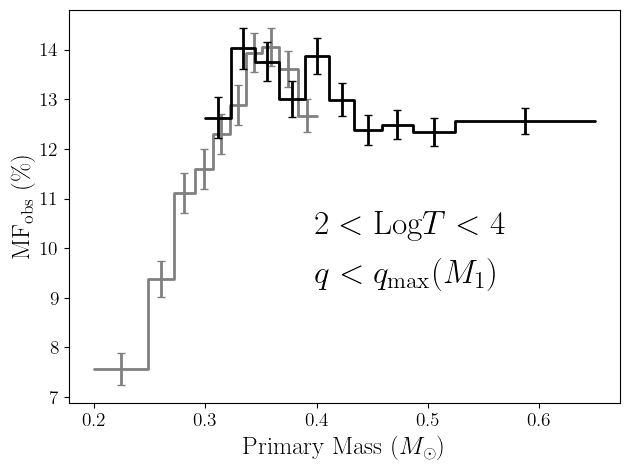

In [5]:
adjusted_res_0204, adjusted_sigma_0204 = period_adjust(res_0204, likelihood_sets_0204)
adjusted_res_0306, adjusted_sigma_0306 = period_adjust(res_0306, likelihood_sets_0306)

c_0306 = "k"
c_0204 = "grey"
lw = 2
capsize = 3

percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10

masses = np.array([t["mass_single"] for t in mdwarfs_0204])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
plt.errorbar(bin_centers, adjusted_res_0204*100, yerr=(adjusted_sigma_0204*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0204, zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*adjusted_res_0204).repeat(2), c=c_0204, lw=lw, zorder=1, solid_capstyle='round');

masses = np.array([t["mass_single"] for t in mdwarfs_0306])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
plt.errorbar(bin_centers, adjusted_res_0306*100, yerr=(adjusted_sigma_0306*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0306, zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*adjusted_res_0306).repeat(2), c=c_0306, lw=lw, zorder=1, solid_capstyle='round');

plt.figtext(0.5, 0.5, r"$2 < \text{Log}T < 4$", fontsize=24);
plt.figtext(0.5, 0.4, r"$q<q_\text{max}(M_1)$", fontsize=24)
plt.xlabel(f"Primary Mass ($M_\odot$)");
plt.ylabel(r"MF$_\text{obs}$ (\%)")
#plt.ylabel(r"$f_b(q<q_{\text{max}} \mid 2 < \text{Log}T < 4)$ (\%)");

plt.tight_layout()
plt.savefig("./plots/results.png", dpi=800, transparent=True);

#### Extrapolating to all mass ratios
We are going to just work with a uniform mass ratio distribution
- in each mass bin, go to each object
    - based on its qmax, extrapolate to the amount of missed binaries
- add the resulting number of binaries and compute the new binary fraction

In [9]:
def adjustment(fb, count, uprate):
    bin_count = fb*count
    single_count = (1-fb)*count

    new_fb = (bin_count*uprate) / (single_count + bin_count*uprate)
    return new_fb
    

def q_adjust(res, likelihood_sets, catalogue):
    bin_counts = np.zeros(len(likelihood_sets))
    bin_adjustment = np.zeros(len(likelihood_sets))
    
    masses = np.array([row["mass_single"] for row in catalogue])
    percs = np.percentile(masses, np.arange(0, 110, 10))
    for i in range(10):
        objs = catalogue[(catalogue["mass_single"] > percs[i]) & (catalogue["mass_single"] < percs[i+1])]
        bin_counts[i] = len(objs)
        bin_adjustment[i] = len(objs)/np.sum(objs["q_max"])

    ind_max = np.argmax(likelihood_sets, axis=1)
    second_derivative = np.array([likelihood_sets[i,ind_max[i] + 1] - 2 * likelihood_sets[i,ind_max[i]] + likelihood_sets[i,ind_max[i] - 1] for i in range(len(likelihood_sets))])/dtheta**2 
    sigma = 1 / np.sqrt(-second_derivative)
    
    adjusted_res = adjustment(res[:,0], bin_counts, bin_adjustment)
    adjusted_sigma = adjustment(res[:,0]+sigma, bin_counts, bin_adjustment) - adjusted_res
    
    return adjusted_res, adjusted_sigma

In [10]:
r_0204, s_0204 = q_adjust(res_0204, likelihood_sets_0204, mdwarfs_0204)
r_0306, s_0306 = q_adjust(res_0306, likelihood_sets_0306, mdwarfs_0306)

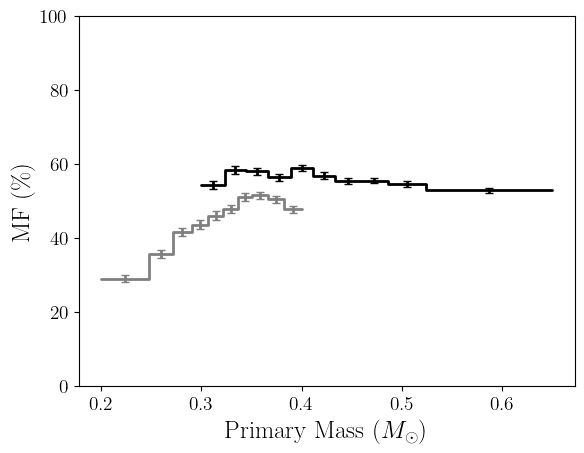

In [11]:
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10

masses = np.array([t["mass_single"] for t in mdwarfs_0204])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
plt.errorbar(bin_centers, r_0204*100, yerr=(s_0204*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0204, zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*r_0204).repeat(2), c=c_0204, lw=lw, zorder=1, solid_capstyle='round');

percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10

masses = np.array([t["mass_single"] for t in mdwarfs_0306])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
plt.errorbar(bin_centers, r_0306*100, yerr=(s_0306*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0306, zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*r_0306).repeat(2), c=c_0306, lw=lw, zorder=1, solid_capstyle='round');

plt.ylabel("MF (\%)");
plt.xlabel(f"Primary Mass ($M_\odot$)");
plt.ylim([0,100]);

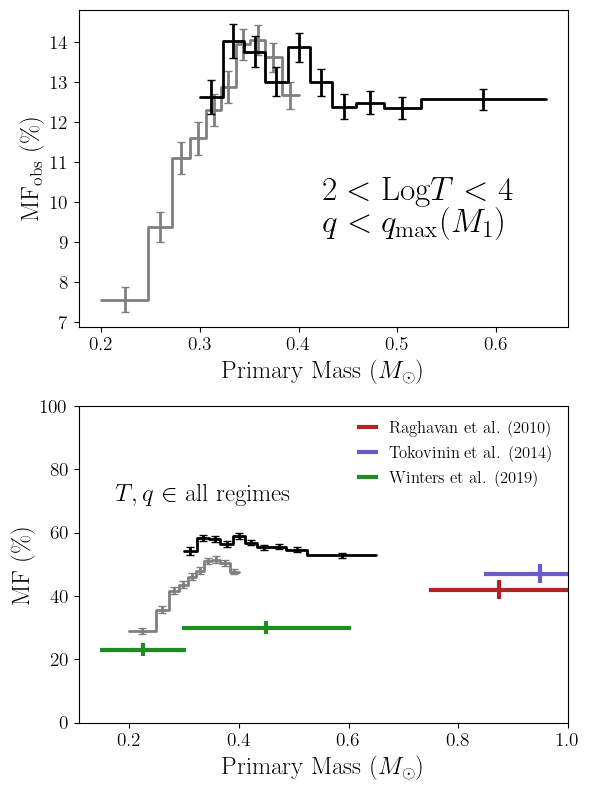

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

adjusted_res_0204, adjusted_sigma_0204 = period_adjust(res_0204, likelihood_sets_0204)
adjusted_res_0306, adjusted_sigma_0306 = period_adjust(res_0306, likelihood_sets_0306)

c_0306 = "k"
c_0204 = "grey"
lw = 2
capsize = 3

percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10

masses = np.array([t["mass_single"] for t in mdwarfs_0204])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
ax1.errorbar(bin_centers, adjusted_res_0204*100, yerr=(adjusted_sigma_0204*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0204, zorder=1)
ax1.plot(mass_lims_b.repeat(2)[1:-1], (100*adjusted_res_0204).repeat(2), c=c_0204, lw=lw, zorder=1, solid_capstyle='round');

masses = np.array([t["mass_single"] for t in mdwarfs_0306])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
ax1.errorbar(bin_centers, adjusted_res_0306*100, yerr=(adjusted_sigma_0306*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0306, zorder=1)
ax1.plot(mass_lims_b.repeat(2)[1:-1], (100*adjusted_res_0306).repeat(2), c=c_0306, lw=lw, zorder=1, solid_capstyle='round');

ax1.text(0.5, 0.4, r"$2 < \text{Log}T < 4$", transform=ax1.transAxes, fontsize=24);
ax1.text(0.5, 0.3, r"$q<q_\text{max}(M_1)$", transform=ax1.transAxes, fontsize=24);
ax1.set_xlabel(f"Primary Mass ($M_\odot$)");
#ax1.set_xticks([])
ax1.set_ylabel(r"MF$_\text{obs}$ (\%)")

masses = np.array([t["mass_single"] for t in mdwarfs_0204])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
ax2.errorbar(bin_centers, r_0204*100, yerr=(s_0204*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0204, zorder=1)
ax2.plot(mass_lims_b.repeat(2)[1:-1], (100*r_0204).repeat(2), c=c_0204, lw=lw, zorder=1, solid_capstyle='round');

masses = np.array([t["mass_single"] for t in mdwarfs_0306])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
ax2.errorbar(bin_centers, r_0306*100, yerr=(s_0306*100), fmt='none', lw=lw, capsize=capsize, ecolor=c_0306, zorder=1)
ax2.plot(mass_lims_b.repeat(2)[1:-1], (100*r_0306).repeat(2), c=c_0306, lw=lw, zorder=1, solid_capstyle='round');

def cross(y, err, x, x1, x2, c, label, clw=lw+1):
    ax2.plot([x1, x2], [y, y], c=c, lw=clw, label=label)
    ax2.errorbar(x, y, yerr=err, fmt='none', ecolor=c, lw=clw)

# Raghavan
cross(42, 3, 0.875, 0.75, 1, "firebrick", "Raghavan et al. (2010)")
# Tokovinin
cross(47, 3, 0.95, 0.85, 1, "slateblue", "Tokovinin et al. (2014)")
# Winters
cross(30, 2, 0.45, 0.3, 0.6, "forestgreen", "Winters et al. (2019)")
cross(23, 2, 0.225, 0.15, 0.3, "forestgreen", None)

ax2.text(0.075, 0.7, r"$T,q\in$ all regimes", transform=ax2.transAxes, fontsize=18);
ax2.set_ylabel("MF (\%)");
ax2.set_xlabel(f"Primary Mass ($M_\odot$)");
ax2.set_ylim([0,100]);
ax2.set_xlim(right=1);
ax2.legend(frameon=False, handlelength=1, fontsize=12);

plt.tight_layout()
plt.savefig("./plots/results.pdf", dpi=800, transparent=True);

#### Total binary fraction

In [28]:
def relative_volume_real(mag, plx, dist_range=(100,200), resolution=1000):
    new_plx = adjust_parallax(plx, mag, 17.65) # see where the XP cutoff i
    
    covered_area = np.array([area_in_range_powerlaw((dist_range[0],1000/plx), 2, resolution=resolution) for plx in new_plx])

    total_area = area_in_range_powerlaw(dist_range, 2, resolution=resolution)
    
    return np.clip(covered_area/total_area, 0, 1)

In [35]:
np.arange(0,10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [36]:
def total_fb(res, catalogue, indices=None):
    if indices is None:
        indices = np.arange(0,10)
        
    weights = np.zeros(10)
    masses = np.array([row["mass_single"] for row in catalogue])
    percs = np.percentile(masses, np.arange(0, 110, 10))
    for i in tqdm(range(10)):
        if i in indices:
            objs = catalogue[(catalogue["mass_single"] > percs[i]) & (catalogue["mass_single"] < percs[i+1])]
            vols = relative_volume_real(objs["phot_g_mean_mag"], objs["parallax"], dist_range=(50,200))
            weights[i] = np.sum(1/vols)

    return np.average(res, weights=weights)

In [37]:
total0204 = total_fb(r_0204, mdwarfs_0204)
total0306 = total_fb(r_0306, mdwarfs_0306)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [38]:
total0204, total0306

(np.float64(0.4231671768826146), np.float64(0.5608412509763182))

In [40]:
below_3 = total_fb(r_0204, mdwarfs_0204, indices=np.arange(0,4))

  0%|          | 0/10 [00:00<?, ?it/s]

#### Lower bound binary fraction (cutting out high periods)
For this one, take the fraction of objects above period of 5.5 and remove them

In [ ]:
fbs = np.linspace(0.02,0.98,len(likelihood_sets[0]))
dtheta = fbs[1] - fbs[0]

mu, si = 4, 1.3
high_prange = (5.5,8)
total_prange = (1,8)

area_fraction = area_in_range(high_prange, mu, si)/area_in_range(total_prange, mu, si)
print(f"{area_fraction*100:.2f}%")

12.47%


In [44]:
def remove_periods(fb, a):
    fs = 1-fb  # rate of singles
    nd = a*fb  # number of objects to get rid of
    nb = fb-nd # adjust count of binaries
    return nb/(nb+fs)

In [51]:
print(f"0204: {remove_periods(total0204,area_fraction)*100:.2f}%")
print(f"0306: {remove_periods(total0306,area_fraction)*100:.2f}%")
print(f"<0.3Msun: {remove_periods(below_3,area_fraction)*100:.2f}%")

0204: 39.10%
0306: 52.78%
<0.3Msun: 32.64%


## Combined datasets
and i need to stick together the sc cubes as well :/

In [3]:
sc_cubes_big = pickle.load(open("./data/2026-04-03-65_mdwarfs.pkl", "rb"))
sc_cubes_small = pickle.load(open("./data/2026-04-03-50_mdwarfs.pkl", "rb"))

In [4]:
mdwarfs = Table.read('./data/combined_catalogue_23_04_26.fits', format='fits')

massratios = pd.read_csv("./data/f_003_many_metallicities.csv", delimiter=",")
generate_q_cutoffs(mdwarfs, massratios)

low_mass_objects = mdwarfs[mdwarfs["mass_single"] < 0.4]
high_mass_objects = mdwarfs[mdwarfs["mass_single"] >= 0.4]

In [10]:
mdwarfs = Table.read('./data/0204_final_catalogue.fits', format='fits')

In [16]:
lims = np.linspace(0.2,0.4,11)
rates = np.zeros((2, len(lims)-1))
dists = np.zeros((2, len(lims)-1))
for i, lim in enumerate(lims[:-1]):
    lm_objs = low_mass_objects[(low_mass_objects['mass_single'] > lim) & (low_mass_objects['mass_single'] <= lims[i+1])]
    og_objs = mdwarfs[(mdwarfs['mass_single'] > lim) & (mdwarfs['mass_single'] <= lims[i+1])]
    rates[0, i] = len(lm_objs[lm_objs["ruwe"] > 1.4])/len(lm_objs)
    rates[1, i] = len(og_objs[og_objs["ruwe"] > 1.4])/len(og_objs)
    dists[0, i] = np.median(lm_objs["parallax"])
    dists[1, i] = np.median(og_objs["parallax"])

In [31]:
print_table(mdwarfs, label="Full Sample")
print_table(mdwarfs[mdwarfs["flux_ratio_mean"] > 10**-1.5], label="Removed objects")
print_table(low_mass_objects, label="Further cut")

,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.29,3.39,0.17,0.06,0.09
Counts,259668,250034,8796,435,166,237


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.60,4.04,0.21,0.06,0.09
Counts,71457,68311,2886,149,44,67


,Total,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.55,3.14,0.15,0.06,0.09
Counts,188204,181717,5909,286,122,170


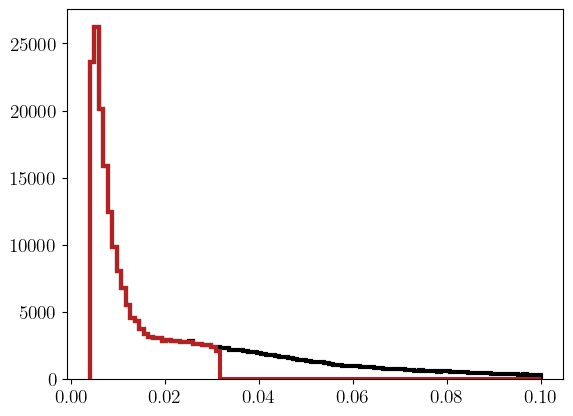

In [29]:
tbins = plt.hist(mdwarfs["flux_ratio_mean"], bins=100, **hist_defaults);
plt.hist(low_mass_objects["flux_ratio_mean"], bins=tbins[1], **hist_defaults);

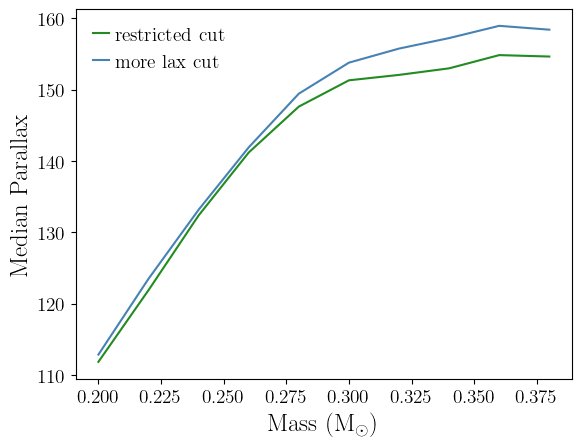

In [18]:
plt.plot(lims[:-1], 1000/dists[0], label="restricted cut", c="forestgreen")
plt.plot(lims[:-1], 1000/dists[1], label="more lax cut", c="steelblue")
plt.xlabel(r"Mass (M$_\odot$)")
plt.ylabel("Median Parallax")
plt.legend()
plt.show()

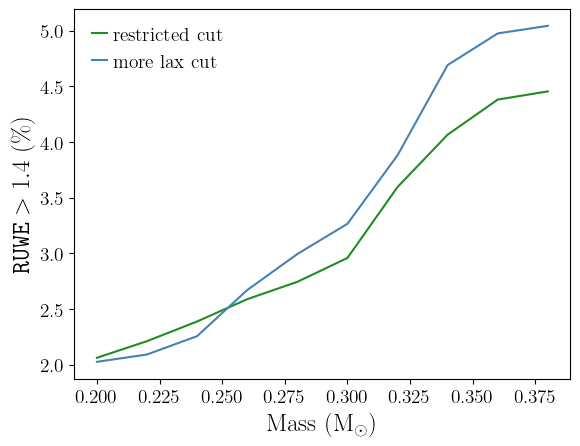

In [15]:
plt.plot(lims[:-1], rates[0]*100, label="restricted cut", c="forestgreen")
plt.plot(lims[:-1], rates[1]*100, label="more lax cut", c="steelblue")
plt.xlabel(r"Mass (M$_\odot$)")
plt.ylabel(r"$\texttt{RUWE} > 1.4$ (\%)")
plt.legend()
plt.show()

In [5]:
indices = [0,5,7,9,12]
all_low_mass_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type", "q_max"]

masses = np.array([row["mass_single"] for row in low_mass_objects])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(low_mass_objects):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_low_mass_mdwarfs.append(df)
all_low_mass_mdwarfs = np.array(all_low_mass_mdwarfs)

percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_low_mass_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
low_mass_objects["mass"] = low_mass_objects["mass_single"]

  0%|          | 0/188204 [00:00<?, ?it/s]

In [19]:
indices = [0,5,7,9,12]
all_high_mass_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type", "q_max"]

masses = np.array([row["mass_single"] for row in high_mass_objects])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(high_mass_objects):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_high_mass_mdwarfs.append(df)
all_high_mass_mdwarfs = np.array(all_high_mass_mdwarfs)

percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_high_mass_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
high_mass_objects["mass"] = high_mass_objects["mass_single"]

  0%|          | 0/155442 [00:00<?, ?it/s]

In [6]:
def mass_binned_data(sc_cubes, catalogue, p_model=(4,2), q_model=0, model_cube_size=(15,15), scale=5):
    fb_results = []
    likelihood_sets = []

    for mass_index in tqdm(range(len(mass_lims))):
        temp_catalogue = []
        for _, obj in enumerate(catalogue):
            if mass_index == 0:
                if obj["mass"] < mass_lims[0]:
                    temp_catalogue.append(obj)
            else:
                if (mass_lims[mass_index-1] < obj["mass"]) & (obj["mass"] <= mass_lims[mass_index]):
                    temp_catalogue.append(obj)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model, q_model=q_model)
        synthsampler = Sampler.popsampler(sc_cubes, temp_catalogue, model_cube=model_cube)
        _, likelihoods = synthsampler.binarity(resolution=2500, scale=scale, verbose=False)
        fb_results.append(synthsampler.fb_estimator())
        likelihood_sets.append(likelihoods)
        print(f'{synthsampler.fb_estimator()[0]*100:.2f} +- {synthsampler.fb_estimator()[1]*100:.2f}')
    fb_results = np.array(fb_results)
    likelihood_sets = np.array(likelihood_sets)
    return fb_results, likelihood_sets

In [7]:
model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=0)
synth_results, likelihood_sets = mass_binned_data(sc_cubes_small, all_low_mass_mdwarfs, p_model=(4,1.3), q_model=0, model_cube_size=(35,25), scale=5)

  0%|          | 0/10 [00:00<?, ?it/s]

22.78 +- 2.23
28.08 +- 2.57
28.85 +- 2.57
30.16 +- 2.57
30.20 +- 2.46
33.39 +- 2.46
32.85 +- 2.38
32.46 +- 2.30
30.31 +- 2.11
31.04 +- 2.04


In [21]:
model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=0)
synth_results, likelihood_sets = mass_binned_data(sc_cubes_big, all_high_mass_mdwarfs, p_model=(4,1.3), q_model=0, model_cube_size=(35,25), scale=5)

  0%|          | 0/10 [00:00<?, ?it/s]

30.50 +- 2.15
29.81 +- 2.11
26.74 +- 1.92
27.28 +- 1.88
26.51 +- 1.77
28.05 +- 1.81
26.55 +- 1.69
26.36 +- 1.65
26.59 +- 1.58
29.43 +- 1.65


### bullshit

In [45]:
mdwarfs = Table.read('./data/combined_catalogue_23_04_26.fits', format='fits')

massratios = pd.read_csv("./data/f_003_many_metallicities.csv", delimiter=",")
generate_q_cutoffs(mdwarfs, massratios)

indices = [0,5,7,9,12]
all_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type", "q_max"]

percentiles = np.linspace(0,100,21) # 20 bins!
masses = np.array([row["mass_single"] for row in mdwarfs])
perc_mass = np.percentile(masses, percentiles)
for row in tqdm(mdwarfs):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], perc_mass) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)
all_mdwarfs = np.array(all_mdwarfs)

masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims = np.percentile(masses, percentiles[1:]) # upper limits 
mdwarfs["mass"] = mdwarfs["mass_single"]

  0%|          | 0/343646 [00:00<?, ?it/s]

In [29]:
def mass_binned_data(sc_cubes_small, sc_cubes_big, catalogue, p_model=(4,2), q_model=0, model_cube_size=(15,15), scale=5):
    fb_results = []
    likelihood_sets = []

    for mass_index in tqdm(range(len(mass_lims))):
        temp_catalogue = []
        for _, obj in enumerate(catalogue):
            if mass_index == 0:
                if obj["mass"] < mass_lims[0]:
                    temp_catalogue.append(obj)
            else:
                if (mass_lims[mass_index-1] < obj["mass"]) & (obj["mass"] <= mass_lims[mass_index]):
                    temp_catalogue.append(obj)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model, q_model=q_model)
        synthsampler = Sampler.popsampler(sc_cubes_small, temp_catalogue, backup_sc=sc_cubes_big, model_cube=model_cube)
        _, likelihoods = synthsampler.binarity(resolution=2500, scale=scale, verbose=False)
        fb_results.append(synthsampler.fb_estimator())
        likelihood_sets.append(likelihoods)
        print(f'{synthsampler.fb_estimator()[0]*100:.2f}')
    fb_results = np.array(fb_results)
    likelihood_sets = np.array(likelihood_sets)
    return fb_results, likelihood_sets

In [30]:
model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=0)
synth_results, likelihood_sets = mass_binned_data(sc_cubes_small, sc_cubes_big, all_mdwarfs, p_model=(4,1.3), q_model=0, model_cube_size=(35,25), scale=5)

  0%|          | 0/20 [00:00<?, ?it/s]

22.90
28.08
28.08
28.74
28.43
30.12
32.04
31.16
30.50
28.66
30.12
30.47
28.97
26.89
27.20
26.89
26.16
28.24
25.39
29.70


In [31]:
outdata = dict()
outdata["meta"] = dict()
outdata["notes"] = "horribly stitched together"
outdata["data"] = synth_results, likelihood_sets

outfile = open(f'./plot_data/{date.today()}_stitched.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [53]:
def adjustment(fb, count, uprate):
    bin_count = fb*count
    single_count = (1-fb)*count

    new_fb = (bin_count*uprate) / (single_count + bin_count*uprate)
    return new_fb
    

def q_adjust(res, likelihood_sets, catalogue):
    bin_counts = np.zeros(len(likelihood_sets))
    bin_adjustment = np.zeros(len(likelihood_sets))
    
    masses = np.array([row["mass_single"] for row in catalogue])
    percs = np.percentile(masses, percentiles)
    for i in range(len(percentiles)-1):
        objs = catalogue[(catalogue["mass_single"] > percs[i]) & (catalogue["mass_single"] < percs[i+1])]
        bin_counts[i] = len(objs)
        bin_adjustment[i] = len(objs)/np.sum(objs["q_max"])

    ind_max = np.argmax(likelihood_sets, axis=1)
    second_derivative = np.array([likelihood_sets[i,ind_max[i] + 1] - 2 * likelihood_sets[i,ind_max[i]] + likelihood_sets[i,ind_max[i] - 1] for i in range(len(likelihood_sets))])/dtheta**2 
    sigma = 1 / np.sqrt(-second_derivative)
    
    adjusted_res = adjustment(res[:,0], bin_counts, bin_adjustment)
    adjusted_sigma = adjustment(res[:,0]+sigma, bin_counts, bin_adjustment) - adjusted_res
    
    return adjusted_res, adjusted_sigma

In [54]:
fbs = np.linspace(0.02,0.98,len(likelihood_sets[0]))
dtheta = fbs[1] - fbs[0]

rates, sigmas = q_adjust(synth_results, likelihood_sets, mdwarfs)

In [55]:
rates

array([0.44490084, 0.52410427, 0.53099495, 0.54368226, 0.54297393,
       0.56578179, 0.59004409, 0.58193674, 0.57593231, 0.55596525,
       0.57440013, 0.57853802, 0.56059794, 0.53489342, 0.5380867 ,
       0.53266567, 0.52160532, 0.54495804, 0.50240541, 0.53400146])

In [68]:
percentiles = np.linspace(0,100,21) # 20 bins!
masses = np.array([row["mass_single"] for row in mdwarfs])
perc_mass = np.percentile(masses, percentiles)
print(perc_mass)

[0.20000602 0.24962018 0.27339585 0.29111697 0.30622914 0.32013898
 0.33387473 0.34662014 0.35963067 0.37312029 0.38692174 0.40064055
 0.41392788 0.42760536 0.4418468  0.45700249 0.4730966  0.49180349
 0.51439926 0.546532   0.64999616]


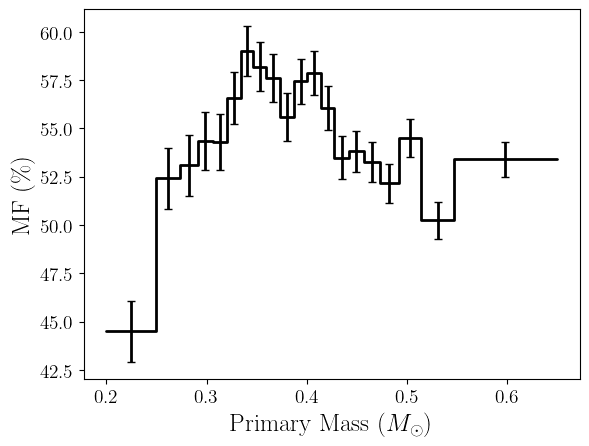

In [61]:
mass_lims_b = np.percentile(masses, percentiles)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
plt.errorbar(bin_centers, rates*100, yerr=(sigmas*100), fmt='none', lw=2, capsize=3, ecolor="k", zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*rates).repeat(2), c="k", lw=2, zorder=1, solid_capstyle='round');

plt.ylabel("MF (\%)");
plt.xlabel(f"Primary Mass ($M_\odot$)");
#plt.ylim([0,100]);

## the grids aren't identical but that's fine

In [3]:
sc_cubes_big = pickle.load(open("./data/2026-04-03-65_mdwarfs.pkl", "rb"))
sc_cubes_small = pickle.load(open("./data/2026-04-03-50_mdwarfs.pkl", "rb"))

In [25]:
vals = np.zeros((10,3))
for i in range(10):
    for j in range(3):
        lams = sc_cubes_small["meta"]["lambdas"][i][j]**(1/4)
        ldex = np.argmin(abs(lams-1))
        vals[i,j] = sc_cubes_small["hist"][i][j][:,ldex,2].sum()

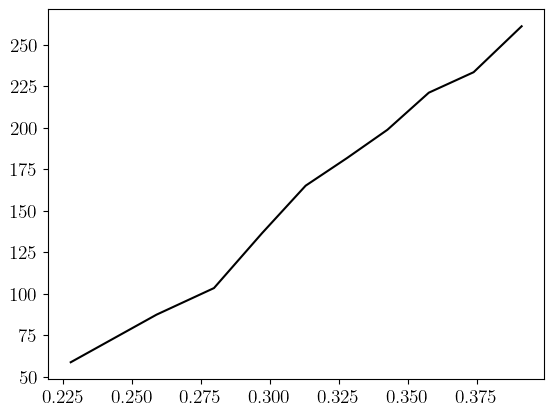

In [36]:
plt.plot(sc_cubes_small["meta"]["mass_grid"], np.mean(vals, axis=1))

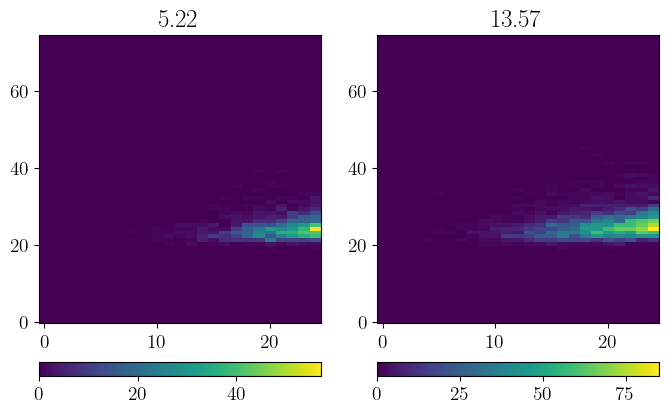

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
s_grid = sc_cubes_small["hist"][0][1][:,:,2]
im0 = axs[0].imshow(s_grid, aspect="auto")
axs[0].set_title(f"{np.sum(s_grid/250):.2f}")
axs[0].invert_yaxis()
l_grid = sc_cubes_small["hist"][4][1][:,:,2]
im1 = axs[1].imshow(l_grid, aspect="auto")
axs[1].set_title(f"{np.sum(l_grid/250):.2f}")
axs[1].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)

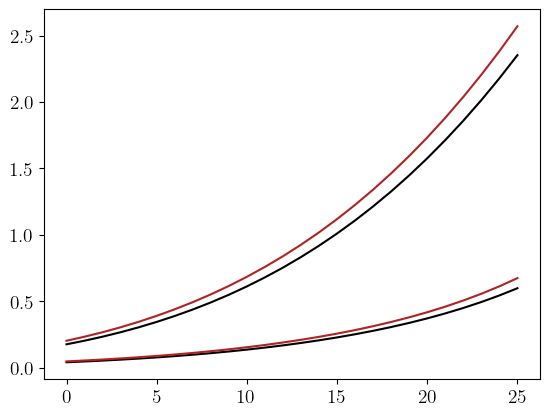

In [20]:
plt.plot(sc_cubes_small["meta"]["lambdas"][0][1], c="k")
plt.plot(q_from_l_vectorized(sc_cubes_small["meta"]["lambdas"][0][0], 0.32, 5), c="k")
plt.plot(sc_cubes_small["meta"]["lambdas"][4][1], c="firebrick")
plt.plot(q_from_l_vectorized(sc_cubes_small["meta"]["lambdas"][4][0], 0.32, 5), c="firebrick")

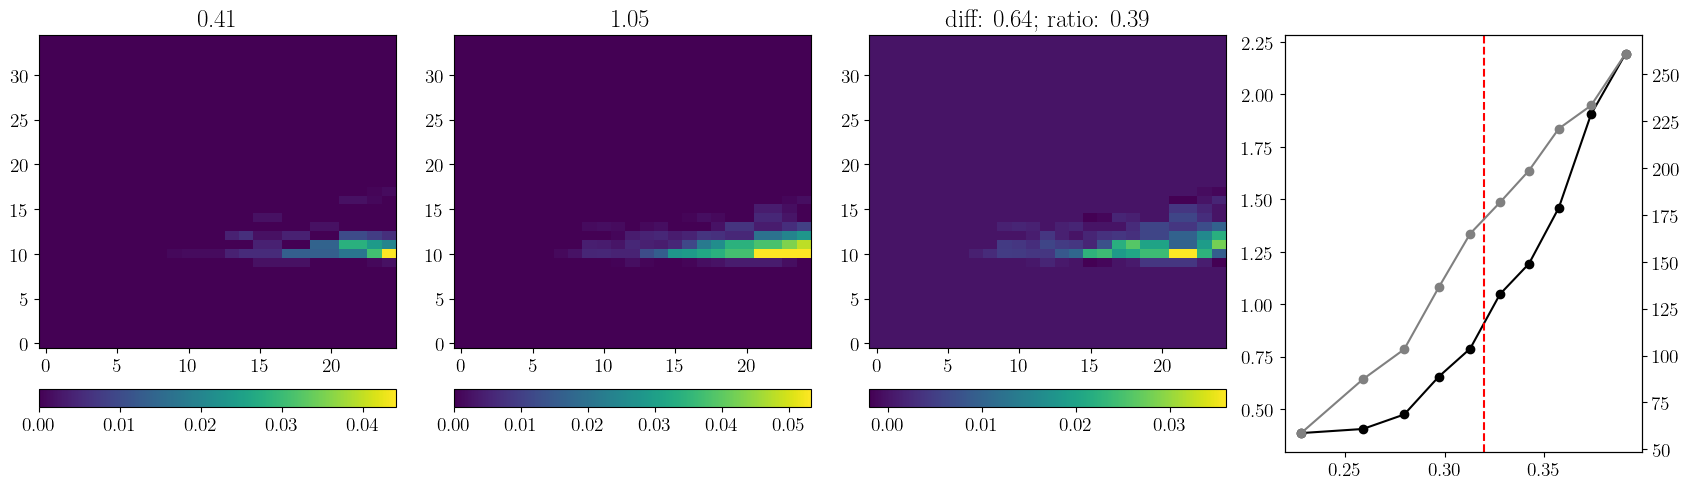

In [37]:
target_object = dict(mass=0.32, parallax=5, soltype_index=2)

target_shape = (35,25)
p_range = (1,8)
q_range = (0.05, 0.5)
p_boundaries = np.linspace(*p_range, target_shape[0]+1)
q_boundaries = np.linspace(*q_range, target_shape[1]+1)

target_object["mass_index"] = 1
lm_grid_l = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

target_object["mass_index"] = 5
lm_grid_h = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

tots = []
for i in range(10):
    target_object["mass_index"] = i
    tots.append(Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries).sum())

fig, axs = plt.subplots(1, 4, figsize=(17, 5))
im0 = axs[0].imshow(lm_grid_l, aspect="auto")
axs[0].set_title(f"{np.sum(lm_grid_l):.2f}")
axs[0].invert_yaxis()
im1 = axs[1].imshow(lm_grid_h, aspect="auto")
axs[1].set_title(f"{np.sum(lm_grid_h):.2f}")
axs[1].invert_yaxis()
im2 = axs[2].imshow(lm_grid_h-lm_grid_l, aspect="auto")
axs[2].set_title(f"diff: {np.sum(lm_grid_h-lm_grid_l):.2f}; ratio: {np.sum(lm_grid_l)/np.sum(lm_grid_h):.2f}")
axs[2].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)
fig.colorbar(im2, ax=axs[2], orientation="horizontal", pad=0.1)

axs[3].plot(sc_cubes_small["meta"]["mass_grid"], tots, marker="o")
axs[3].axvline(x=target_object["mass"], **dline)

newax = axs[3].twinx()
newax.plot(sc_cubes_small["meta"]["mass_grid"], np.mean(vals, axis=1), marker="o", color="grey")

plt.tight_layout()

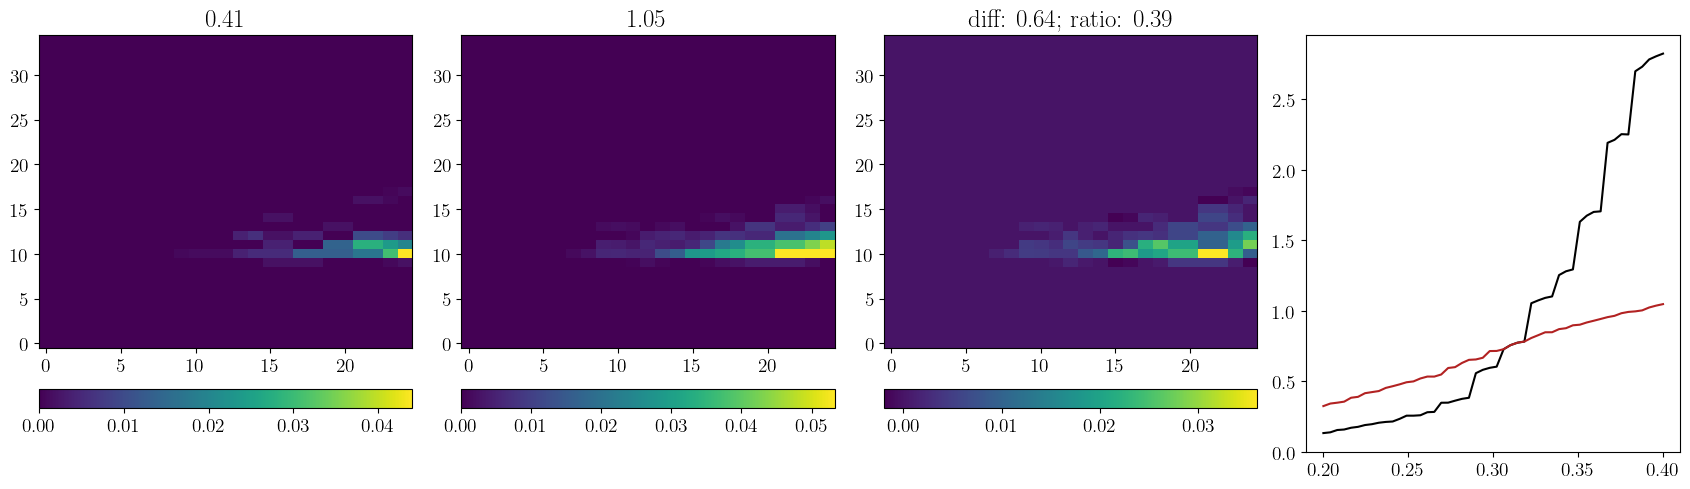

In [5]:
target_object = dict(mass=0.32, parallax=5, soltype_index=2)

target_shape = (35,25)
p_range = (1,8)
q_range = (0.05, 0.5)
p_boundaries = np.linspace(*p_range, target_shape[0]+1)
q_boundaries = np.linspace(*q_range, target_shape[1]+1)

target_object["mass_index"] = 1
lm_grid_l = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

target_object["mass_index"] = 5
lm_grid_h = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

ms = np.linspace(0.2, 0.4, 50)
tots = []
tots_const = []
for i in range(len(ms)):
    target_object["mass_index"] = np.argmin(abs(np.array(sc_cubes_small["meta"]["mass_grid"]) - ms[i])) 
    target_object["mass"] = ms[i]
    tots.append(Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries).sum())
    target_object["mass_index"] = 4
    tots_const.append(Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries).sum())

fig, axs = plt.subplots(1, 4, figsize=(17, 5))
im0 = axs[0].imshow(lm_grid_l, aspect="auto")
axs[0].set_title(f"{np.sum(lm_grid_l):.2f}")
axs[0].invert_yaxis()
im1 = axs[1].imshow(lm_grid_h, aspect="auto")
axs[1].set_title(f"{np.sum(lm_grid_h):.2f}")
axs[1].invert_yaxis()
im2 = axs[2].imshow(lm_grid_h-lm_grid_l, aspect="auto")
axs[2].set_title(f"diff: {np.sum(lm_grid_h-lm_grid_l):.2f}; ratio: {np.sum(lm_grid_l)/np.sum(lm_grid_h):.2f}")
axs[2].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)
fig.colorbar(im2, ax=axs[2], orientation="horizontal", pad=0.1)

axs[3].plot(ms, tots)#, marker="o")
axs[3].plot(ms, tots_const)#, marker="o")
#axs[3].axvline(x=target_object["mass"], **dline)

plt.tight_layout()

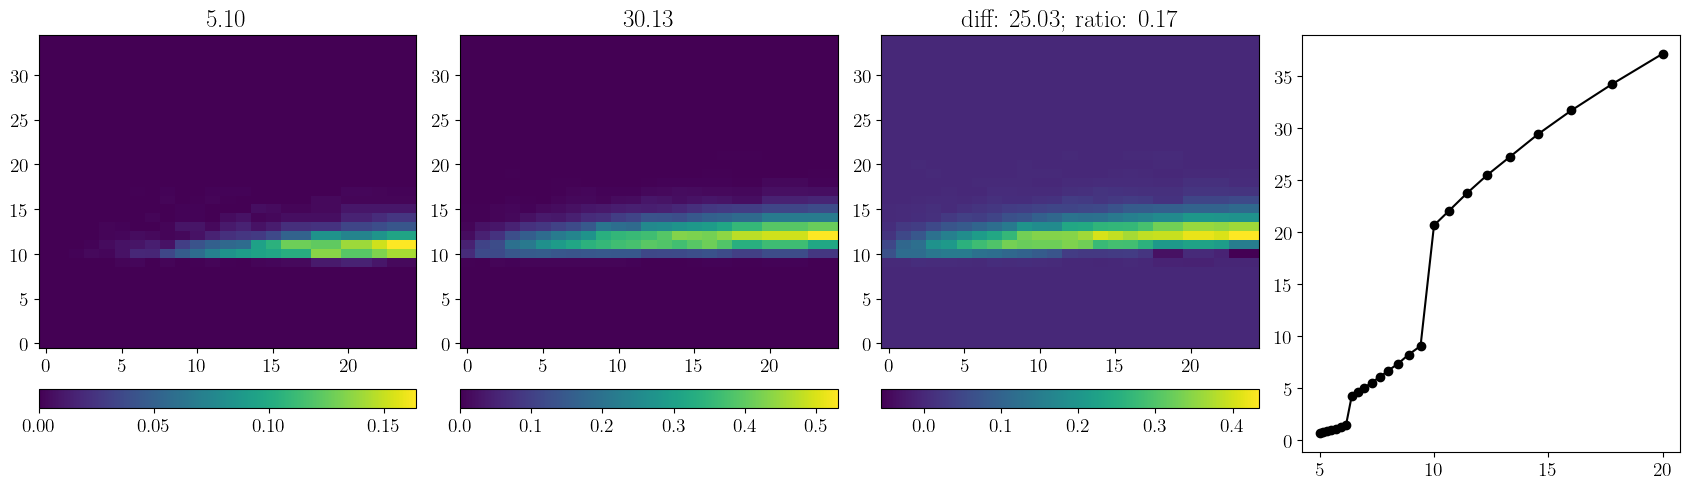

In [6]:
target_object = dict(mass=0.32, mass_index=3, soltype_index=2)

target_shape = (35,25)
p_range = (1,8)
q_range = (0.05, 0.5)
p_boundaries = np.linspace(*p_range, target_shape[0]+1)
q_boundaries = np.linspace(*q_range, target_shape[1]+1)

target_object["parallax"] = 7
lm_grid_l = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

target_object["parallax"] = 15
lm_grid_h = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

plxs = 1000/np.linspace(50,200,25)
tots = []
for i in range(len(plxs)):
    target_object["parallax"] = plxs[i]
    tots.append(Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries).sum())

fig, axs = plt.subplots(1, 4, figsize=(17, 5))
im0 = axs[0].imshow(lm_grid_l, aspect="auto")
axs[0].set_title(f"{np.sum(lm_grid_l):.2f}")
axs[0].invert_yaxis()
im1 = axs[1].imshow(lm_grid_h, aspect="auto")
axs[1].set_title(f"{np.sum(lm_grid_h):.2f}")
axs[1].invert_yaxis()
im2 = axs[2].imshow(lm_grid_h-lm_grid_l, aspect="auto")
axs[2].set_title(f"diff: {np.sum(lm_grid_h-lm_grid_l):.2f}; ratio: {np.sum(lm_grid_l)/np.sum(lm_grid_h):.2f}")
axs[2].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)
fig.colorbar(im2, ax=axs[2], orientation="horizontal", pad=0.1)

axs[3].plot(plxs, tots, marker="o")
#axs[3].axvline(x=target_object["mass"], **dline)

plt.tight_layout()

In [ ]:
target_object = dict(mass=0.32, parallax=10, soltype_index=2)

target_shape = (35,25)
p_range = (1,8)
q_range = (0.05, 0.5)
p_boundaries = np.linspace(*p_range, target_shape[0]+1)
q_boundaries = np.linspace(*q_range, target_shape[1]+1)
        
### big grid
target_object["mass_index"] = 0
hm_grid = Sampler.compute_grid(target_object, sc_cubes_big, p_boundaries, q_boundaries)

### small grid
target_object["mass_index"] = 4
lm_grid = Sampler.compute_grid(target_object, sc_cubes_small, p_boundaries, q_boundaries)

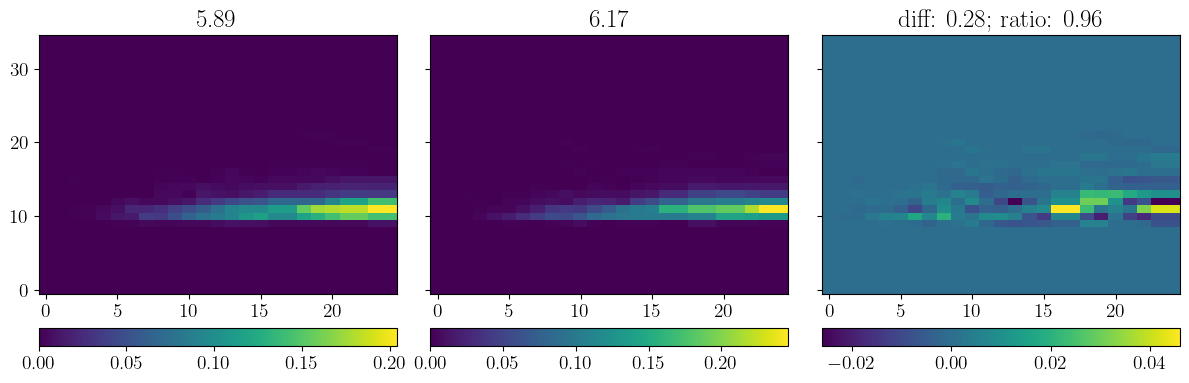

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
im0 = axs[0].imshow(lm_grid, aspect="auto")
axs[0].set_title(f"{np.sum(lm_grid):.2f}")
im1 = axs[1].imshow(hm_grid, aspect="auto")
axs[1].set_title(f"{np.sum(hm_grid):.2f}")
im2 = axs[2].imshow(hm_grid-lm_grid, aspect="auto")
axs[2].set_title(f"diff: {np.sum(hm_grid-lm_grid):.2f}; ratio: {np.sum(lm_grid)/np.sum(hm_grid):.2f}")
axs[2].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)
fig.colorbar(im2, ax=axs[2], orientation="horizontal", pad=0.1)
plt.tight_layout()

## Junk

In [6]:
indata = pickle.load(open("./massive_data/2026-01-20-reference.pkl", "rb"))

In [6]:
synthtable = Table()
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]
for item in relevant_list:
    synthtable[item] = [float(row[item]) for row in indata["data"]]

In [7]:
soltypes = [0,5,7,9,12]
solution_colormap = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]
CMAP = matplotlib.colors.ListedColormap(solution_colormap)

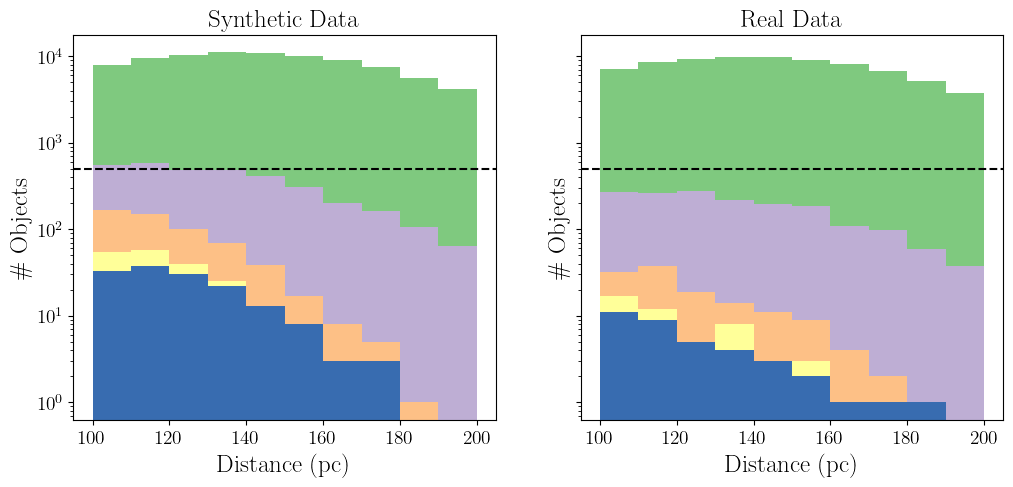

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bincount = 10

using_synth_table = synthtable[synthtable["mass"] < 0.3]
tbins = axs[0].hist(1000/using_synth_table["parallax"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[0].hist(1000/using_synth_table[np.isin(using_synth_table["solution_type"], [5, 7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[0].hist(1000/using_synth_table[np.isin(using_synth_table["solution_type"], [7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[0].hist(1000/using_synth_table[np.isin(using_synth_table["solution_type"], [9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[0].hist(1000/using_synth_table[using_synth_table["solution_type"] == 12]["parallax"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[0].axhline(y=500, color="k", linestyle="--");
axs[0].set_yscale("log");
axs[0].set_xlabel("Distance (pc)");
axs[0].set_ylabel(f"\# Objects");
#axs[0].legend();
axs[0].set_title("Synthetic Data");

using_real_table = mdwarfs[(mdwarfs["mass_single"] < 0.3)];
tbins = axs[1].hist(1000/using_real_table["parallax"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[1].hist(1000/using_real_table[np.isin(using_real_table["solution_type"], [5, 7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[1].hist(1000/using_real_table[np.isin(using_real_table["solution_type"], [7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[1].hist(1000/using_real_table[np.isin(using_real_table["solution_type"], [9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[1].hist(1000/using_real_table[using_real_table["solution_type"] == 12]["parallax"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[1].axhline(y=500, color="k", linestyle="--");
axs[1].set_yscale("log");
axs[1].set_xlabel("Distance (pc)");
axs[1].set_ylabel(f"\# Objects");
#axs[1].legend();
axs[1].set_title("Real Data");

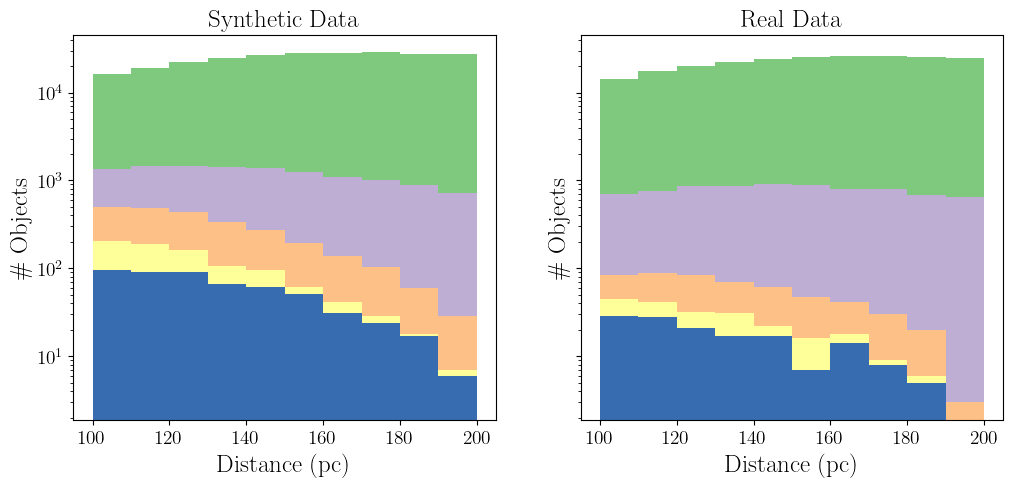

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bincount = 10

tbins = axs[0].hist(1000/synthtable["parallax"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[0].hist(1000/synthtable[np.isin(synthtable["solution_type"], [5, 7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[0].hist(1000/synthtable[np.isin(synthtable["solution_type"], [7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[0].hist(1000/synthtable[np.isin(synthtable["solution_type"], [9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[0].hist(1000/synthtable[synthtable["solution_type"] == 12]["parallax"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[0].set_yscale("log");
axs[0].set_xlabel("Distance (pc)");
axs[0].set_ylabel(f"\# Objects");
#axs[0].legend();
axs[0].set_title("Synthetic Data");

tbins = axs[1].hist(1000/mdwarfs["parallax"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[1].hist(1000/mdwarfs[np.isin(mdwarfs["solution_type"], [5, 7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[1].hist(1000/mdwarfs[np.isin(mdwarfs["solution_type"], [7, 9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[1].hist(1000/mdwarfs[np.isin(mdwarfs["solution_type"], [9, 12])]["parallax"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[1].hist(1000/mdwarfs[mdwarfs["solution_type"] == 12]["parallax"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[1].set_yscale("log");
axs[1].set_xlabel("Distance (pc)");
axs[1].set_ylabel(f"\# Objects");
#axs[1].legend();
axs[1].set_title("Real Data");

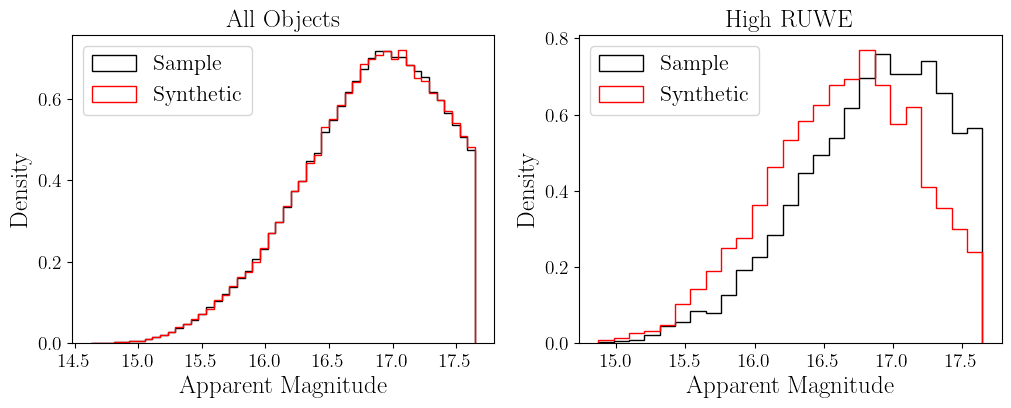

In [8]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

plt.sca(axs[0])
tbins = plt.hist(mdwarfs["phot_g_mean_mag"], color="k", histtype="step", density=True, bins=50, label="Sample");
plt.hist(synthtable["phot_g_mean_mag"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Apparent Magnitude");
plt.ylabel("Density");
plt.title("All Objects");

five_s = synthtable[synthtable["solution_type"] == 5]
five_r = mdwarfs[mdwarfs["solution_type"] == 5]

plt.sca(axs[1])
tbins = plt.hist(five_r["phot_g_mean_mag"], color="k", histtype="step", density=True, bins=25, label="Sample");
plt.hist(five_s["phot_g_mean_mag"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Apparent Magnitude");
plt.ylabel("Density");
plt.title("High RUWE");

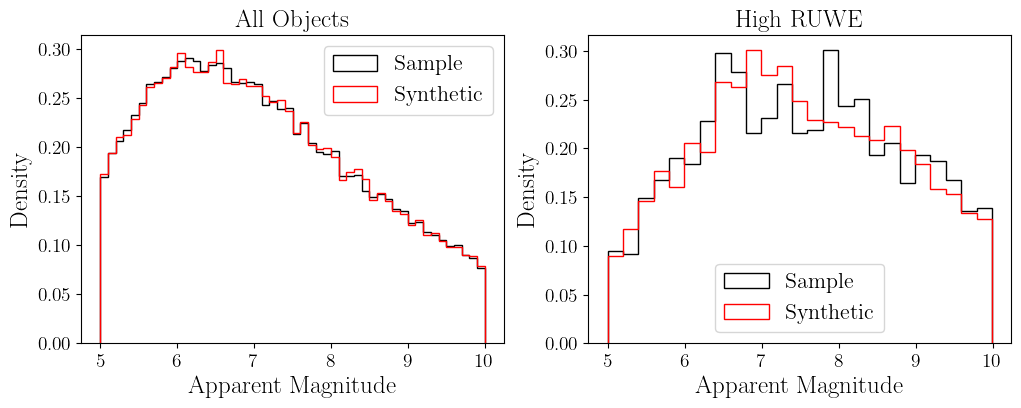

In [11]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

using_mdwarfs = mdwarfs[mdwarfs["mass"] < 0.3]
using_table = synthtable[synthtable["mass"] < 0.3]

plt.sca(axs[0])
tbins = plt.hist(using_mdwarfs["parallax"], color="k", histtype="step", density=True, bins=50, label="Sample");
plt.hist(using_table["parallax"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Apparent Magnitude");
plt.ylabel("Density");
plt.title("All Objects");

five_s = using_table[using_table["solution_type"] == 5]
five_r = using_mdwarfs[using_mdwarfs["solution_type"] == 5]

plt.sca(axs[1])
tbins = plt.hist(five_r["parallax"], color="k", histtype="step", density=True, bins=25, label="Sample");
plt.hist(five_s["parallax"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Apparent Magnitude");
plt.ylabel("Density");
plt.title("High RUWE");

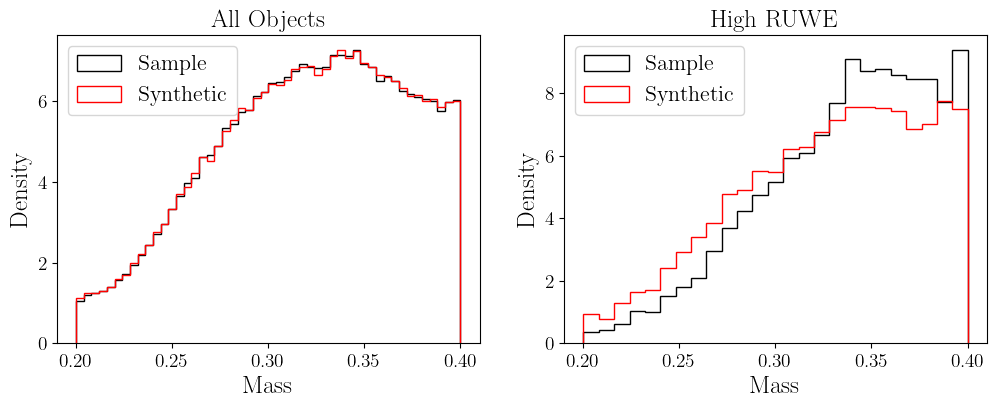

In [100]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

plt.sca(axs[0])
tbins = plt.hist(mdwarfs["mass"], color="k", histtype="step", density=True, bins=50, label="Sample");
plt.hist(synthtable["mass"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Mass");
plt.ylabel("Density");
plt.title("All Objects");


five_s = synthtable[synthtable["solution_type"] == 5]
five_r = mdwarfs[mdwarfs["solution_type"] == 5]

plt.sca(axs[1])
tbins = plt.hist(five_r["mass"], color="k", histtype="step", density=True, bins=25, label="Sample");
plt.hist(five_s["mass"], color="red", histtype="step", density=True, bins=tbins[1], label="Synthetic");
plt.legend();
plt.xlabel("Mass");
plt.ylabel("Density");
plt.title("High RUWE");

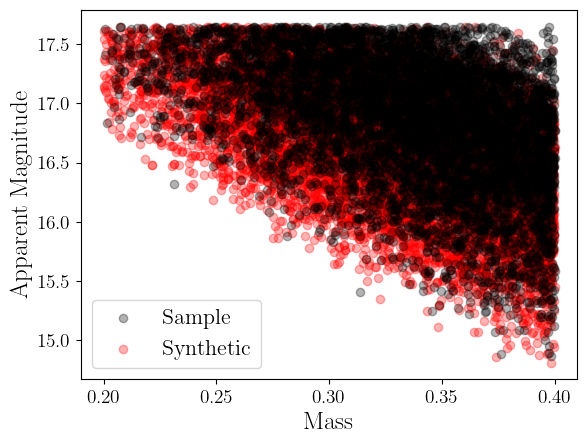

In [108]:
plt.scatter(five_r["mass"], five_r["phot_g_mean_mag"], c="k", alpha=0.3, label="Sample");
plt.scatter(five_s["mass"], five_s["phot_g_mean_mag"], c="r", alpha=0.3, zorder=0, label="Synthetic");
plt.legend();
plt.xlabel("Mass");
plt.ylabel("Apparent Magnitude");

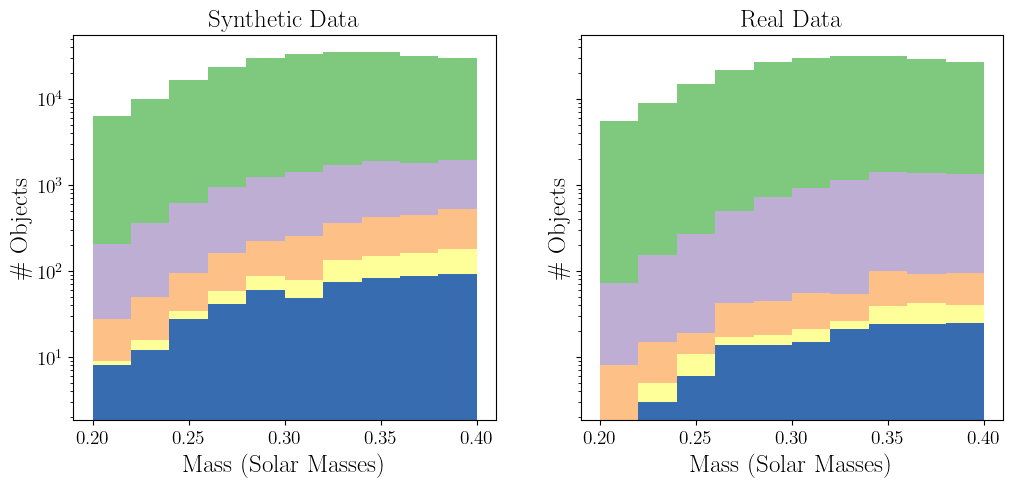

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bincount = 10

tbins = axs[0].hist(synthtable["mass"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[0].hist(synthtable[np.isin(synthtable["solution_type"], [5, 7, 9, 12])]["mass"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[0].hist(synthtable[np.isin(synthtable["solution_type"], [7, 9, 12])]["mass"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[0].hist(synthtable[np.isin(synthtable["solution_type"], [9, 12])]["mass"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[0].hist(synthtable[synthtable["solution_type"] == 12]["mass"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[0].set_yscale("log");
axs[0].set_xlabel("Mass (Solar Masses)");
axs[0].set_ylabel(f"\# Objects");
#axs[0].legend();
axs[0].set_title("Synthetic Data");

tbins = axs[1].hist(mdwarfs["mass_single"], color=solution_colormap[0], bins=bincount, label="Low RUWE");
axs[1].hist(mdwarfs[np.isin(mdwarfs["solution_type"], [5, 7, 9, 12])]["mass_single"], bins=tbins[1], color=solution_colormap[1], label="High RUWE");
axs[1].hist(mdwarfs[np.isin(mdwarfs["solution_type"], [7, 9, 12])]["mass_single"], bins=tbins[1], color=solution_colormap[2], label="Acceleration");
axs[1].hist(mdwarfs[np.isin(mdwarfs["solution_type"], [9, 12])]["mass_single"], bins=tbins[1], color=solution_colormap[3], label="Jerk");
axs[1].hist(mdwarfs[mdwarfs["solution_type"] == 12]["mass_single"], bins=tbins[1], color=solution_colormap[4], label="Full Orbit");
axs[1].set_yscale("log");
axs[1].set_xlabel("Mass (Solar Masses)");
axs[1].set_ylabel(f"\# Objects");
#axs[1].legend();
axs[1].set_title("Real Data");

In [58]:
def vols(dset):   
    indices = [0,5,7,9,12]
    reduced_cat = []
    for row in tqdm(dset):
        df = dict()
        df["soltype_index"] = indices.index(row["solution_type"])   
        df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
        for item in relevant_list:
            df[item] = float(row[item])
        reduced_cat.append(df)
    reduced_cat = np.array(reduced_cat)

    vols = [[],[],[],[],[],[],[],[],[],[]]
    hr_vols = [[],[],[],[],[],[],[],[],[],[]]
    ns_vols = [[],[],[],[],[],[],[],[],[],[]]

    for obj in reduced_cat:
        vols[obj["mass_index"]].append(relative_volume(obj["phot_g_mean_mag"], obj["parallax"]))
        if obj["soltype_index"] == 1:
            hr_vols[obj["mass_index"]].append(relative_volume(obj["phot_g_mean_mag"], obj["parallax"]))
        elif obj["soltype_index"] > 1:
            ns_vols[obj["mass_index"]].append(relative_volume(obj["phot_g_mean_mag"], obj["parallax"]))
    return vols, hr_vols, ns_vols

r_vols, r_hr_vols, r_ns_vols = vols(mdwarfs)
s_vols, s_hr_vols, s_ns_vols = vols(synthtable)

r_means = [np.mean(np.array(r_vols[i])) for i in range(len(r_vols))]
r_hr_means = [np.mean(np.array(r_hr_vols[i])) for i in range(len(r_hr_vols))]
r_ns_means = [np.mean(np.array(r_ns_vols[i])) for i in range(len(r_ns_vols))]
s_means = [np.mean(np.array(s_vols[i])) for i in range(len(s_vols))]
s_hr_means = [np.mean(np.array(s_hr_vols[i])) for i in range(len(s_hr_vols))]
s_ns_means = [np.mean(np.array(s_ns_vols[i])) for i in range(len(s_ns_vols))]

  0%|          | 0/225536 [00:00<?, ?it/s]

  0%|          | 0/250000 [00:00<?, ?it/s]

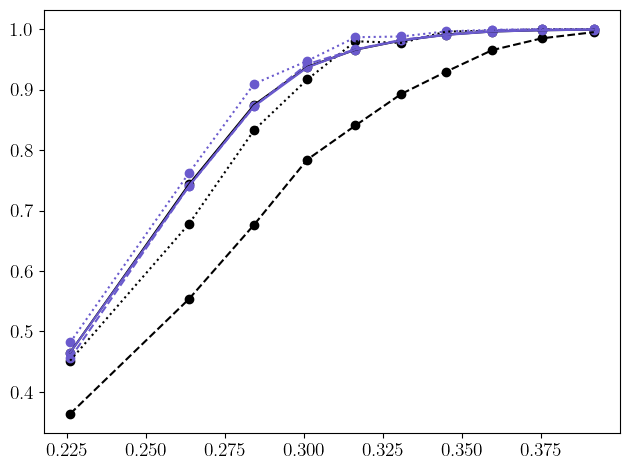

In [59]:
#fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

#plt.sca(axs[0])
plt.plot(bin_centers, r_means, c="k");
plt.plot(bin_centers, r_hr_means, c="k", linestyle="--");
plt.plot(bin_centers, r_ns_means, c="k", linestyle=":");
plt.scatter(bin_centers, r_means, c="k");
plt.scatter(bin_centers, r_hr_means, c="k");
plt.scatter(bin_centers, r_ns_means, c="k");
#plt.sca(axs[1])
plt.plot(bin_centers, s_means, c="slateblue");
plt.plot(bin_centers, s_hr_means, c="slateblue", linestyle="--");
plt.plot(bin_centers, s_ns_means, c="slateblue", linestyle=":");
plt.scatter(bin_centers, s_means, c="slateblue");
plt.scatter(bin_centers, s_hr_means, c="slateblue");
plt.scatter(bin_centers, s_ns_means, c="slateblue");

plt.tight_layout()

In [26]:
indata["data"][4]

{'ra': np.float64(269.2397567354848),
 'dec': np.float64(12.9776008859011),
 'pmra': np.float64(-4.13589711366574),
 'pmdec': np.float64(-22.931070588969973),
 'parallax': np.float64(5.294711626092709),
 'mass': np.float64(0.30141586),
 'phot_g_mean_mag': np.float64(17.53566),
 'bp_rp': np.float64(2.8727455),
 'is_binary': True,
 'solution_type': 0,
 'period': np.float64(121.23128455584155),
 'm2': np.float64(0.12417328819242252),
 'q': np.float64(0.4119666702091341),
 'ecc': np.float64(0.2873248080448257),
 'inc': np.float64(1.8099622620039006),
 'w': np.float64(3.185319285763799),
 'omega': np.float64(0.6622171395372305),
 'Tp': np.float64(47.59194407236233)}

In [31]:
def compute_plx_over_error(obj):
    if obj["is_binary"]:
        t_ast_yr, psi, plx_factor, ast_obs, ast_err = sd.gw.gaiamock.predict_astrometry_luminous_binary(ra = obj['ra'], dec = obj['dec'], parallax = obj["parallax"], 
                            pmra = obj["pmra"], pmdec = obj["pmdec"], m1 = obj["mass"], m2 = obj["q"]*obj["mass"], period = obj["period"], Tp = obj["Tp"], ecc = obj["ecc"], 
                            omega = obj["omega"], inc = obj["inc"], w = obj["w"], phot_g_mean_mag = obj["phot_g_mean_mag"], f = 1e-10, data_release = "dr3", c_funcs = c_funcs)
    else:
         t_ast_yr, psi, plx_factor, ast_obs, ast_err = sd.gw.gaiamock.predict_astrometry_single_source(ra = obj['ra'], dec = obj['dec'], parallax = obj["parallax"], 
                            pmra = obj["pmra"], pmdec = obj["pmdec"], phot_g_mean_mag = obj["phot_g_mean_mag"], data_release = "dr3", c_funcs = c_funcs)
         
    five_fit = sd.gw.gaiamock.fit_5par_solution_only(t_ast_yr, psi, plx_factor, ast_obs, ast_err)
    obj["plx_over_error"] = five_fit[4]/five_fit[9]
    return obj

In [33]:
working_catalogue = indata["data"]

In [ ]:
counter = 0
for i in tqdm(range(len(working_catalogue))):
    working_catalogue[i] = compute_plx_over_error(working_catalogue[i])
    plxerr = working_catalogue[i]["plx_over_error"]
    if plxerr < 10:
        counter += 1
        print(f"{counter}/{i}: {counter/i*100:.1f}%, {plxerr:.2f}")

plx over error does not matter

In [ ]:
weights = 1/np.array(r_means)#np.array([np.mean(1/np.array(vols[i])) for i in range(len(vols))])

In [ ]:
synth_results[:,0], weights

(array([0.1352461 , 0.17289316, 0.20170468, 0.21476591, 0.21707083,
        0.23627851, 0.25817527, 0.25702281, 0.25164466, 0.23973589]),
 array([2.62375203, 1.36832393, 1.15165362, 1.07118614, 1.03667022,
        1.01928172, 1.00959557, 1.00398764, 1.00152263, 1.00075626]))

np.float64(0.20593639548284987)

In [67]:
print(synth_results[:,0]*100)
print(f"{np.average(synth_results[:,0], weights=weights)*100:.2f}")
print(f'q<0.5: {np.average(synth_results[:,0], weights=weights)*100:.2f}')#+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(np.average(synth_results[:,0], weights=weights), a)
#total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}')#+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(np.average(synth_results[:,0], weights=weights), period_scaling)
#obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}')#+-{obs_sigma*100:.2f}')

[13.52460984 17.28931573 20.17046819 21.47659064 21.70708283 23.62785114
 25.81752701 25.70228091 25.16446579 23.97358944]
20.88
q<0.5: 20.88
all: 43.26
q<0.5, 2<T<4: 10.47


In [ ]:
print(synth_results[:,0]*100)
print(f"{np.average(synth_results[:,0], weights=weights)*100:.2f}")

[12.87154862 17.55822329 20.70828331 22.01440576 22.12965186 23.97358944
 26.08643457 25.77911164 25.31812725 23.74309724]
20.99


In [65]:
print(f'q<0.5: {np.average(synth_results[:,0], weights=weights)*100:.2f}')#+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0)/Sampler.area_in_range_powerlaw((0.05,0.5), 0)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,5.5), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(np.average(synth_results[:,0], weights=weights), a)
#total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}')#+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(np.average(synth_results[:,0], weights=weights), period_scaling)
#obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}')#+-{obs_sigma*100:.2f}')

q<0.5: 20.99
all: 35.93
q<0.5, 2<T<4: 11.85


## Preamble

In [5]:
percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
def convert_to_usable(sc_cubes, mass_index):
    target_mass = sc_cubes["meta"]["reference_masses"][mass_index]
    
    out_sc_cube = {}
    out_sc_cube["data"] = sc_cubes["data"][mass_index]
    out_sc_cube["meta"] = {}
    out_sc_cube["meta"]["shape"] = sc_cubes["meta"]["shape"]
    out_sc_cube["meta"]["lambdas"] = np.array(sc_cubes["meta"]["lambdas"][mass_index])
    out_sc_cube["meta"]["periods"] = sc_cubes["meta"]["periods"]
    out_sc_cube["meta"]["parallaxes"] = sc_cubes["meta"]["parallaxes"]
    
    # out_catalogue = []
    # for i in range(3):
    #     out_catalogue = out_catalogue + sc_cubes["meta"]["memory_reduced_catalogue"][mass_index][i]

    # pull out only what we need
    memory_reduced = []
    # relevant_list = ["parallax", "mass", "solution_type", "phot_g_mean_mag"]
    # for row in out_catalogue: 
    #     df = dict()
    #     for item in relevant_list:
    #         working_item = item
    #         if item == "mass":
    #             working_item = "mass_single"
    #         df[item] = float(row[working_item])
    #     memory_reduced.append(df)
    
    return out_sc_cube, memory_reduced

def mass_binned_data(sc_cubes, catalogue, mass_binned=False, p_model=(4,2), pcut=None, q_model=0, model_cube_size=(15,15), scale=5):
    synth_results = []
    likelihood_set = []

    for mass_index in tqdm(range(len(mass_lims))):
        temp_catalogue = []
        for _, obj in enumerate(catalogue):
            if mass_index == 0:
                if obj["mass"] < mass_lims[0]:
                    temp_catalogue.append(obj)
            else:
                if (mass_lims[mass_index-1] < obj["mass"]) & (obj["mass"] <= mass_lims[mass_index]):
                    temp_catalogue.append(obj)
        
        # reduce to only mandatory objects to save on memory
        working_catalogue = []
        relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]
        for row in temp_catalogue:
            df = dict()
            df["mass_index"] = mass_index
            for item in relevant_list:
                df[item] = float(row[item])
            working_catalogue.append(df)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model, q_model=q_model, pcut=pcut)
        out_sc_cube = sc_cubes
        if mass_binned:
            out_sc_cube, _ = convert_to_usable(sc_cubes, mass_index)
        synthsampler = Sampler.popsampler(out_sc_cube, working_catalogue, model_cube=model_cube)
        _, likelihoods = synthsampler.binarity(resolution=2500, scale=scale, verbose=False)
        likelihood_set.append(likelihoods)
        synth_results.append(synthsampler.fb_estimator())
        print(f'{synthsampler.fb_estimator()[0]*100:.2f}')
    synth_results = np.array(synth_results)
    likelihood_set = np.array(likelihood_set)
    return synth_results, likelihood_set

def generate_plot(synth_results, target_fb=None):
    plt.errorbar(mass_lims, synth_results[:,0], yerr=(synth_results[:,2], synth_results[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
    plt.scatter(mass_lims, synth_results[:,0], marker='o', zorder=2);
    if target_fb is not None:
        plt.axhline(y=target_fb, c="green", linestyle="--");

In [6]:
sc_cubes = pickle.load(open("./data/2026-03-19-mass_binned_mod_mdwarfs.pkl", "rb"))
synth_results, likelihood_set = mass_binned_data(sc_cubes, all_mdwarfs, mass_binned=True, p_model=(4,1.3), q_model=0.5, model_cube_size=(25,15), scale=3)

  0%|          | 0/10 [00:00<?, ?it/s]

14.95
19.09
22.44
23.82
24.09
25.97
28.28
28.01
27.39
25.93


In [52]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
synth_results, likelihood_set = mass_binned_data(sc_cubes, all_mdwarfs, mass_binned=True, p_model=(4,1.3), q_model=0, pcut=(1,5.5), model_cube_size=(35,25), scale=3)

  0%|          | 0/10 [00:00<?, ?it/s]

12.87
17.56
20.71
22.01
22.13
23.97
26.09
25.78
25.32
23.74


In [5]:
outdata = dict()
outdata["meta"] = dict()
outdata["notes"] = "2026.01.23 Real data. Mass binned results for mdwarfs with parallax cuts and 3-parameter luminosity function with turnover. p=(4,1.3), q=0.5, model cube size (25,15), scale=2."
outdata["data"] = dict()
outdata["data"] = synth_results
outdata["likelihoods"] = likelihood_set

outfile = open(f'./plot_data/{date.today()}-real_data_pcut.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [8]:
synth_results = pickle.load(open("./plot_data/2026-02-01-real_data.pkl", "rb"))["data"]
synth_results_pcut = pickle.load(open("./plot_data/2026-02-02-real_data_pcut.pkl", "rb"))["data"]

In [5]:
import style

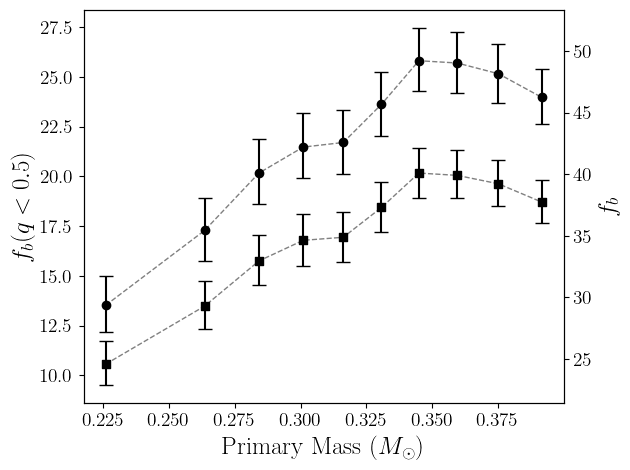

In [34]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

plt.errorbar(bin_centers, 100*synth_results[:,0], yerr=(100*synth_results[:,2], 100*synth_results[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, 100*synth_results[:,0], marker='o', c="k", zorder=2);
plt.plot(bin_centers, 100*synth_results[:,0], c="grey", linestyle="--", lw=1, zorder=1);

plt.errorbar(bin_centers, 100*synth_results_pcut[:,0], yerr=(100*synth_results_pcut[:,2], 100*synth_results_pcut[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, 100*synth_results_pcut[:,0], marker='s', c="k", zorder=2);
plt.plot(bin_centers, 100*synth_results_pcut[:,0], c="grey", linestyle="--", lw=1, zorder=1);
plt.xlabel(f"Primary Mass ($M_\odot$)");
#plt.ylabel(f"Fit Binary Fraction (\%)");
plt.ylabel(r"$f_b(q<0.5)$");

ymin, ymax = plt.ylim()
ax = plt.twinx();
ax.set_ylim(Sampler.convert_binarity(ymin/100, a)*100, Sampler.convert_binarity(ymax/100, a)*100);
#ax.set_ylabel("Total Binary Fraction");
ax.set_ylabel(r"$f_b$");
plt.tight_layout();
plt.savefig("./plots/extrapolated_real_data.png", dpi=800, transparent=True)

In [4]:
synth_results = pickle.load(open("./plot_data/2026-02-05-real_data_pcut.pkl", "rb"))["data"]
likelihood_set = pickle.load(open("./plot_data/2026-02-05-real_data_pcut.pkl", "rb"))["likelihoods"]

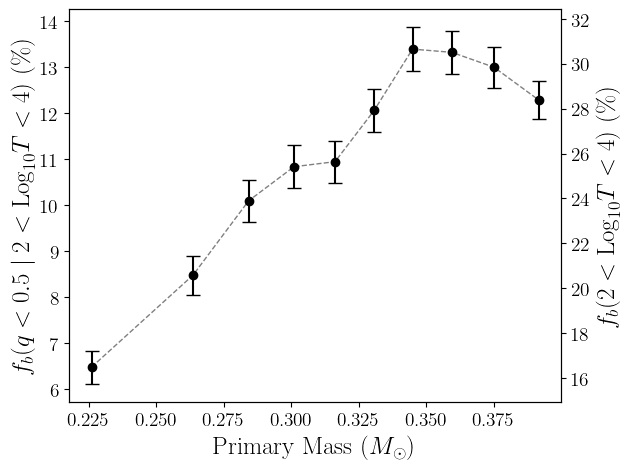

In [33]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)
new_results = np.zeros(synth_results.shape)
new_results[:,0] = Sampler.convert_binarity(synth_results[:,0], period_scaling)

fbs = np.linspace(0.02,0.98,len(likelihood_set[0]))
dtheta = fbs[1] - fbs[0]

# First panel: flat binarity
ind_max = np.argmax(likelihood_set, axis=1)
second_derivative = np.array([likelihood_set[i,ind_max[i] + 1] - 2 * likelihood_set[i,ind_max[i]] + likelihood_set[i,ind_max[i] - 1] for i in range(len(likelihood_set))])/dtheta**2 
sigma = 1 / np.sqrt(-second_derivative)

sigma_m = new_results[:,0] - Sampler.convert_binarity(synth_results[:,0] - sigma, period_scaling) # only need to do one side, it's the same
#sigma_p = (synth_results[:,0] + sigma)*period_scaling - new_results[:,0]

plt.errorbar(bin_centers, 100*new_results[:,0], yerr=(100*sigma_m), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, 100*new_results[:,0], marker='o', c="k", zorder=2);
plt.plot(bin_centers, 100*new_results[:,0], c="grey", linestyle="--", lw=1, zorder=1);

plt.xlabel(f"Primary Mass ($M_\odot$)");
#plt.ylabel(r"$f_{b,obs}(q<0.5)$");
plt.ylabel(r"$f_b(q<0.5 \mid 2 < \text{Log}_{10}T < 4)$ (\%)");

ymin, ymax = plt.ylim()
ax = plt.twinx();
ax.set_ylim(Sampler.convert_binarity(ymin/100, a)*100, Sampler.convert_binarity(ymax/100, a)*100);
ax.set_ylabel(r"$f_b(2 < \text{Log}_{10}T < 4)$ (\%)");
#ax.set_ylabel(r"$f_{b,obs}$");
plt.tight_layout();
plt.savefig("./plots/real_data_detectable.pdf", dpi=800, transparent=True)

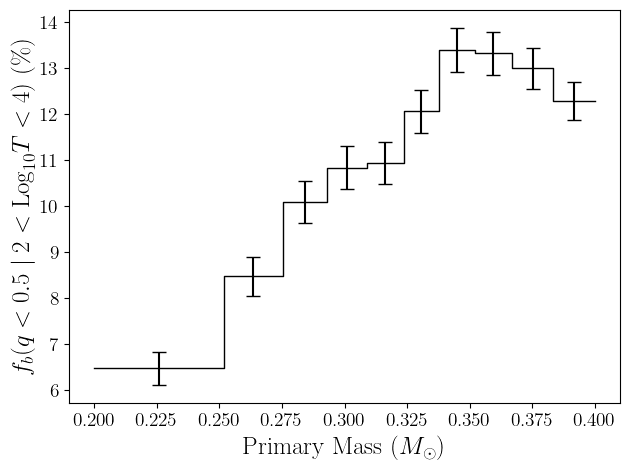

In [7]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)
new_results = np.zeros(synth_results.shape)
new_results[:,0] = Sampler.convert_binarity(synth_results[:,0], period_scaling)

fbs = np.linspace(0.02,0.98,len(likelihood_set[0]))
dtheta = fbs[1] - fbs[0]

# First panel: flat binarity
ind_max = np.argmax(likelihood_set, axis=1)
second_derivative = np.array([likelihood_set[i,ind_max[i] + 1] - 2 * likelihood_set[i,ind_max[i]] + likelihood_set[i,ind_max[i] - 1] for i in range(len(likelihood_set))])/dtheta**2 
sigma = 1 / np.sqrt(-second_derivative)

sigma_m = new_results[:,0] - Sampler.convert_binarity(synth_results[:,0] - sigma, period_scaling) # only need to do one side, it's the same
#sigma_p = (synth_results[:,0] + sigma)*period_scaling - new_results[:,0]

plt.errorbar(bin_centers, 100*new_results[:,0], yerr=(100*sigma_m), fmt='none', capsize=5, ecolor='k', zorder=1);
#plt.scatter(bin_centers, 100*new_results[:,0], marker='o', c="k", zorder=2);
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*new_results[:,0]).repeat(2), c="k", lw=1, zorder=1);

plt.xlabel(f"Primary Mass ($M_\odot$)");
#plt.ylabel(r"$f_{b,obs}(q<0.5)$");
plt.ylabel(r"$f_b(q<0.5 \mid 2 < \text{Log}_{10}T < 4)$ (\%)");

ymin, ymax = plt.ylim()
#ax = plt.twinx();
#ax.set_ylim(Sampler.convert_binarity(ymin/100, a)*100, Sampler.convert_binarity(ymax/100, a)*100);
#ax.set_ylabel(r"$f_b(2 < \text{Log}_{10}T < 4)$ (\%)");
#ax.set_ylabel(r"$f_{b,obs}$");
plt.tight_layout();
plt.savefig("./plots/real_data_detectable.png", dpi=800, transparent=True)

In [32]:
100*new_results[:,0], 100*sigma_m

(array([ 6.48160225,  8.47802474, 10.09120566, 10.83218504, 10.94218668,
        12.05710584, 13.38531659, 13.31567251, 12.99204164, 12.28339339]),
 array([0.36107282, 0.42027658, 0.45870385, 0.46734065, 0.4553108 ,
        0.46806488, 0.48342432, 0.46696246, 0.44131309, 0.40794111]))

[[0.05993463 0.00646907 0.00595835]
 [0.07661802 0.00715002 0.00680954]
 [0.08938591 0.0074905  0.00697978]
 [0.09517403 0.0074905  0.00697978]
 [0.09619546 0.00715002 0.00697978]
 [0.10470739 0.00715002 0.00697978]
 [0.11441099 0.00732026 0.00680954]
 [0.11390027 0.00697978 0.00663931]
 [0.11151693 0.00663931 0.00646907]
 [0.10623954 0.00629883 0.00595835]]


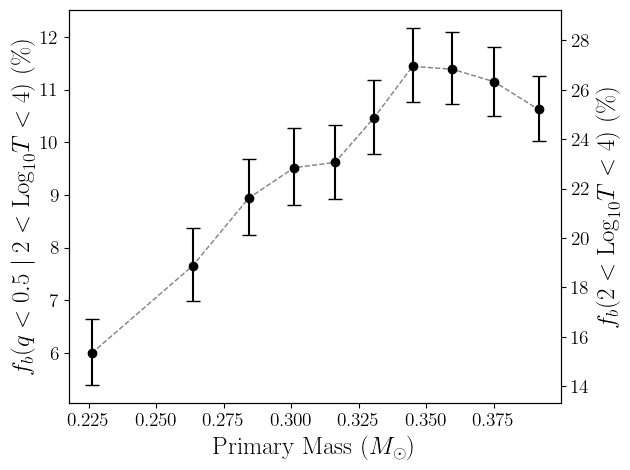

In [ ]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)
new_results = np.zeros(synth_results.shape)
new_results[:,0] = synth_results[:,0]*period_scaling
new_results[:,2] = new_results[:,0] - (synth_results[:,0] - synth_results[:,2])*period_scaling
new_results[:,1] = (synth_results[:,0] + synth_results[:,1])*period_scaling - new_results[:,0]
print(new_results)

plt.errorbar(bin_centers, 100*new_results[:,0], yerr=(100*new_results[:,2], 100*new_results[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, 100*new_results[:,0], marker='o', c="k", zorder=2);
plt.plot(bin_centers, 100*new_results[:,0], c="grey", linestyle="--", lw=1, zorder=1);

plt.xlabel(f"Primary Mass ($M_\odot$)");
#plt.ylabel(r"$f_{b,obs}(q<0.5)$");
plt.ylabel(r"$f_b(q<0.5 \mid 2 < \text{Log}_{10}T < 4)$ (\%)");

ymin, ymax = plt.ylim()
ax = plt.twinx();
ax.set_ylim(Sampler.convert_binarity(ymin/100, a)*100, Sampler.convert_binarity(ymax/100, a)*100);
ax.set_ylabel(r"$f_b(2 < \text{Log}_{10}T < 4)$ (\%)");
#ax.set_ylabel(r"$f_{b,obs}$");
plt.tight_layout();
plt.savefig("./plots/real_data_detectable.png", dpi=800, transparent=True)

In [ ]:
final_results = np.zeros(synth_results.shape)
final_results[:,0] = Sampler.convert_binarity(new_results[:,0], a)
final_results[:,2] = final_results[:,0] - Sampler.convert_binarity(new_results[:,0] - new_results[:,2], a)
final_results[:,1] = Sampler.convert_binarity(new_results[:,0] + new_results[:,1], a) - final_results[:,0]
final_results*100

array([[15.55008507,  1.49141453,  1.40292248],
       [19.33156094,  1.55766331,  1.51803596],
       [22.08785871,  1.56474063,  1.49252632],
       [23.30027093,  1.5360539 ,  1.46484647],
       [23.511898  ,  1.46226538,  1.4600418 ],
       [25.24895267,  1.42350129,  1.42090617],
       [27.17318745,  1.41367654,  1.34420748],
       [27.07335866,  1.35075904,  1.3123436 ],
       [26.60538813,  1.29506731,  1.2879224 ],
       [25.55668364,  1.24968863,  1.20514062]])

In [22]:
mass_lims_b

array([0.20000301, 0.25191136, 0.27521697, 0.29309791, 0.30884883,
       0.32356067, 0.33788007, 0.35194775, 0.36699972, 0.3832147 ,
       0.3999998 ])

## Do q as well

In [3]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
mass_index=5
temp_catalogue = []
model_cube_size, p_model, scale = (50,50), (4,1.3), 10
for obj in all_mdwarfs:
    if obj["mass_index"] == mass_index:
        temp_catalogue.append(obj)
        
model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model)
synthsampler = Sampler.popsampler(sc_cubes, temp_catalogue, model_cube=model_cube)
grids = synthsampler.assign_grids(temp_catalogue, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=scale)

  0%|          | 0/22553 [00:00<?, ?it/s]

In [4]:
gammas, likelihoods_l = synthsampler.q_along_grid(p_model=(4,1.3), fb=0.25, pcut=5,
                    p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                    grids=grids, catalogue=temp_catalogue, model_cube=model_cube, mass_binned=True, scale=scale, verbose=True)

Reducing catalogue...
Calculating likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

Complete!


In [9]:
gammas, likelihoods_h = synthsampler.q_along_grid(p_model=(4,1.3), fb=0.21, pcut=5,
                    p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                    grids=grids, catalogue=temp_catalogue, model_cube=model_cube, mass_binned=True, scale=scale, verbose=True)

Reducing catalogue...
Calculating likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

Complete!


(-3830.0, -3797.191257329805)

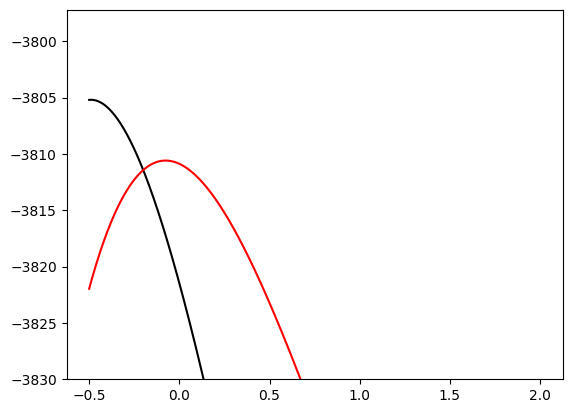

In [10]:
plt.plot(gammas, likelihoods_l, c="k");
plt.plot(gammas, likelihoods_h, c="r");
plt.ylim(bottom=-3830)

In [3]:
def mass_binned_constraining(sc_cubes, catalogue, p_model=(4,1.3), model_cube_size=(35,35), scale=7, discard=200):
    chains = []
    likelihoods = []

    for mass_index in tqdm(range(10)):
        temp_catalogue = []
        for obj in catalogue:
            if obj["mass_index"] == mass_index:
                temp_catalogue.append(obj)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model)
        synthsampler = Sampler.popsampler(sc_cubes, temp_catalogue, model_cube=model_cube)
        grids = synthsampler.assign_grids(temp_catalogue, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=scale)

        synthsampler.constrain_parameters(p_model=p_model, step_count=500, nwalkers=4,
                                        p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                                        grids=grids, catalogue=temp_catalogue, model_cube=model_cube, mass_binned=True, scale=scale, verbose=True)
        
        chain = synthsampler.sampler.get_chain(discard=discard, flat=True)
        likelihood = synthsampler.sampler.get_log_prob(discard=discard, flat=True)
        
        chains.append(chain)
        likelihoods.append(likelihood) 
    return chains, likelihoods

In [ ]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
chains, likelihoods = mass_binned_constraining(sc_cubes, all_mdwarfs, p_model=(4,1.3), model_cube_size=(35,35), scale=7)

In [ ]:
outdata = dict()
outdata["chains"] = chains
outdata["likelihoods"] = likelihoods

outfile = open(f'./plot_data/{date.today()}-real_data_fb_and_gamma.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [17]:
indata = pickle.load(open("./plot_data/2026-02-01-real_data_fb_and_gamma.pkl", "rb"))
chains, likelihoods = indata["chains"], indata["likelihoods"]

In [22]:
mles = []
mlesq = []
for i in range(len(chains)):
    mles.append(corner.quantile(chains[i][:,0], [0.16, 0.5, 0.84], weights=likelihoods[i]))
    mlesq.append(corner.quantile(chains[i][:,1], [0.16, 0.5, 0.84], weights=likelihoods[i]))
mles = np.array(mles)
mlesq = np.array(mlesq)

In [21]:
percentiles_b = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110])-10
masses = np.array([t["mass_single"] for t in mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

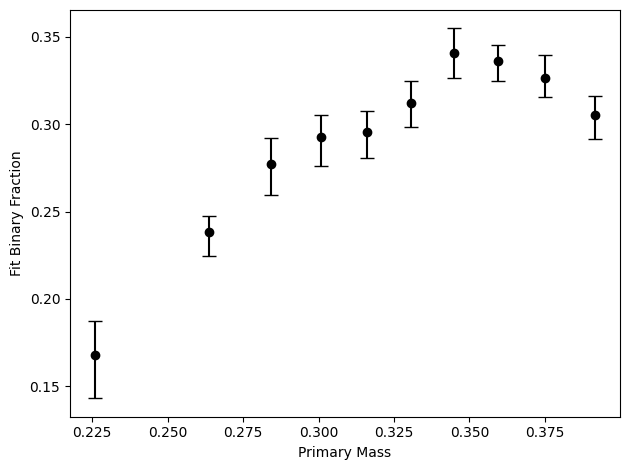

In [23]:
plt.errorbar(bin_centers, mles[:,1], yerr=(mles[:,1]-mles[:,0], mles[:,2]-mles[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, mles[:,1], marker='o', c="k", zorder=2);
plt.xlabel("Primary Mass");
plt.ylabel("Fit Binary Fraction");
ymin, ymax = plt.ylim()
plt.tight_layout();
#plt.savefig("./plots/2026-01-23-real_data.png", dpi=800)

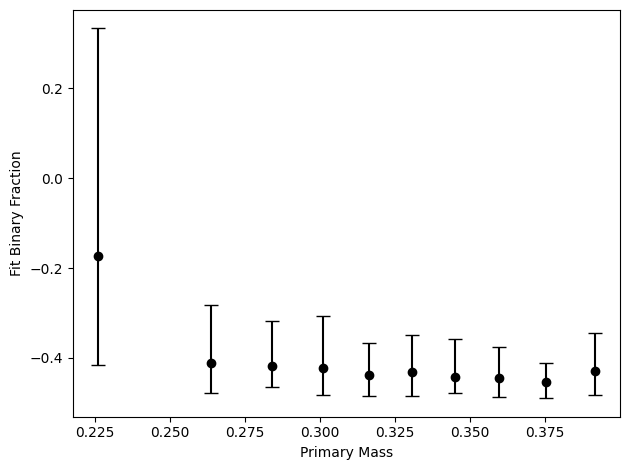

In [24]:
plt.errorbar(bin_centers, mlesq[:,1], yerr=(mlesq[:,1]-mlesq[:,0], mlesq[:,2]-mlesq[:,1]), fmt='none', capsize=5, ecolor='k', zorder=1);
plt.scatter(bin_centers, mlesq[:,1], marker='o', c="k", zorder=2);
plt.xlabel("Primary Mass");
plt.ylabel("Fit Binary Fraction");
ymin, ymax = plt.ylim()
plt.tight_layout();
#plt.savefig("./plots/2026-01-23-real_data.png", dpi=800)

call the corner.quantiles() function [0.16,0.5,0.84]

## Single binary fraction for the whole sample

In [4]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
model_cube = Sampler.create_model_cube((25,15), p_model=(4,1.3), q_model=0.5)
synthsampler = Sampler.popsampler(sc_cubes, all_mdwarfs[::3], model_cube=model_cube)
_, likelihoods = synthsampler.binarity(resolution=2500, scale=3, mass_binned=True, verbose=True)

Reducing catalogue...
Computing grids...


  0%|          | 0/75179 [00:00<?, ?it/s]

Computing likelihoods...


  0%|          | 0/2500 [00:00<?, ?it/s]

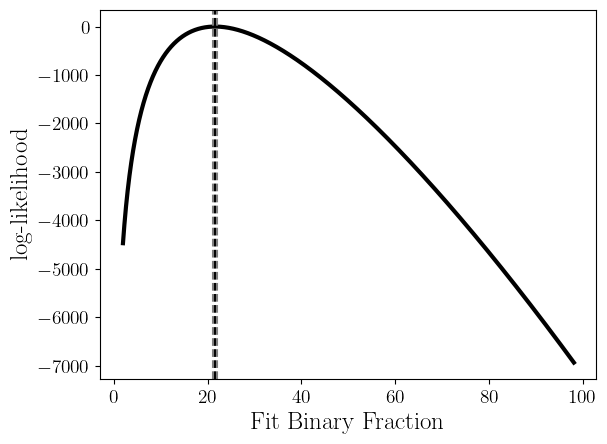

In [5]:
fbs = np.linspace(0.02, 0.98, 2500)
mledx = np.argmax(likelihoods)
sigma = Sampler.fisher_uncertainty(likelihoods)
plt.plot(fbs*100, likelihoods - np.max(likelihoods), c="black", linewidth=3);
plt.axvline(x=fbs[mledx]*100, c="k", linestyle="--");
plt.axvline(x=(fbs[mledx]+sigma)*100, c="grey", linestyle="--");
plt.axvline(x=(fbs[mledx]-sigma)*100, c="grey", linestyle="--");

plt.xlabel("Fit Binary Fraction");
plt.ylabel("log-likelihood");

In [ ]:
gamma = 0.5
fb = 0.14
print(f'q<0.5, 2<T<4: {fb*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), gamma)/Sampler.area_in_range_powerlaw((0.05,0.5), gamma)
period_scaling = Sampler.area_in_range((1,8), 4, 1.3, resolution=500)/Sampler.area_in_range((2,4), 4, 1.3, resolution=500)
print(a, period_scaling)
period_mle = Sampler.convert_binarity(fb, period_scaling)
total_mle = Sampler.convert_binarity(period_mle, a)

print(f'q<0.5: {period_mle*100:.2f}')
print(f'all: {total_mle*100:.2f}')

period_mle = fb*period_scaling
total_mle = Sampler.convert_binarity(period_mle, a)

print(f'q<0.5: {period_mle*100:.2f}')
print(f'all: {total_mle*100:.2f}')

q<0.5, 2<T<4: 14.00
2.88811017662093 2.2565600557481886
q<0.5: 26.87
all: 51.48
q<0.5: 31.59
all: 57.15


In [13]:
gamma = 0.5
fb = 0.14
print(f'q<0.5, {fb*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), gamma)/Sampler.area_in_range_powerlaw((0.05,0.5), gamma)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)
print(a, period_scaling)
period_mle = Sampler.convert_binarity(fb, period_scaling)
total_mle = Sampler.convert_binarity(fb, a)

print(f'q<0.5, 2<T<4: {period_mle*100:.2f}')
print(f'all: {total_mle*100:.2f}')

period_mle = fb*period_scaling
total_mle = Sampler.convert_binarity(fb, a)

print(f'q<0.5, 2<T<4: {period_mle*100:.2f}')
print(f'all: {total_mle*100:.2f}')

q<0.5, 14.00
2.88811017662093 0.44315239802844
q<0.5, 2<T<4: 6.73
all: 31.98
q<0.5, 2<T<4: 6.20
all: 31.98


In [6]:
print(f'q<0.5: {fbs[mledx]*100:.2f}')#+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(fbs[mledx], a)
#total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}')#+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(fbs[mledx], period_scaling)
#obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}')#+-{obs_sigma*100:.2f}')

q<0.5: 21.59
all: 44.30
q<0.5, 2<T<4: 10.88


In [7]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
model_cube = Sampler.create_model_cube((25,15), p_model=(4,1.3), q_model=0, pcut=(1,5.5))
synthsampler = Sampler.popsampler(sc_cubes, all_mdwarfs[::3], model_cube=model_cube)
_, likelihoods = synthsampler.binarity(resolution=2500, scale=3, mass_binned=True, verbose=True)

Reducing catalogue...
Computing grids...


  0%|          | 0/75179 [00:00<?, ?it/s]

Computing likelihoods...


  0%|          | 0/2500 [00:00<?, ?it/s]

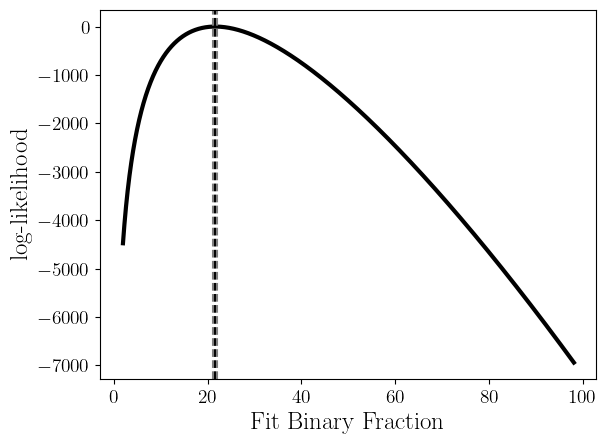

In [8]:
fbs = np.linspace(0.02, 0.98, 2500)
mledx = np.argmax(likelihoods)
sigma = Sampler.fisher_uncertainty(likelihoods)
plt.plot(fbs*100, likelihoods - np.max(likelihoods), c="black", linewidth=3);
plt.axvline(x=fbs[mledx]*100, c="k", linestyle="--");
plt.axvline(x=(fbs[mledx]+sigma)*100, c="grey", linestyle="--");
plt.axvline(x=(fbs[mledx]-sigma)*100, c="grey", linestyle="--");

plt.xlabel("Fit Binary Fraction");
plt.ylabel("log-likelihood");

In [ ]:
print(f'q<0.5: {0.205*100:.2f}')#+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(0.205, a)
#total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}')#+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(0.205, period_scaling)
#obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}')#+-{obs_sigma*100:.2f}')

q<0.5: 20.00
all: 34.55
q<0.5, 2<T<4: 11.23


In [9]:
print(f'q<0.5: {fbs[mledx]*100:.2f}')#+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0)/Sampler.area_in_range_powerlaw((0.05,0.5), 0)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,5.5), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(fbs[mledx], a)
#total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}')#+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(fbs[mledx], period_scaling)
#obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}')#+-{obs_sigma*100:.2f}')

q<0.5: 21.63
all: 36.82
q<0.5, 2<T<4: 12.26


In [15]:
outdata = dict()
outdata["fbs"] = fbs
outdata["likelihoods"] = likelihoods
outdata["res"] = (mledx, sigma)

outfile = open(f'./plot_data/total_fb.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [19]:
f'q<0.5 {fbs[mledx]*100:.2f}+-{sigma[0]*100:.2f}'

'q<0.5 21.63+-0.39'

In [8]:
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,8), 4, 1.3, resolution=500)
adjusted_mle = Sampler.convert_binarity(fbs[mledx], period_scaling)
adjusted_sigma = Sampler.convert_binarity(fbs[mledx]+sigma[0], period_scaling) - adjusted_mle
f'q<0.5, 2<T<4: {adjusted_mle*100:.2f}+-{adjusted_sigma*100:.2f}'

'q<0.5, 2<T<4: 10.88+-0.22'

In [9]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
per_mle = Sampler.convert_binarity(adjusted_mle, a)
per_sigma = Sampler.convert_binarity(adjusted_mle+adjusted_sigma, a) - per_mle
f'2<T<4: {per_mle*100:.2f}+-{per_sigma*100:.2f}'

'2<T<4: 26.06+-0.44'

In [10]:
a = Sampler.area_in_range_powerlaw((0.05,1), 0.5)/Sampler.area_in_range_powerlaw((0.05,0.5), 0.5)
total_mle = Sampler.convert_binarity(fbs[mledx], a)
total_sigma = Sampler.convert_binarity(fbs[mledx]+sigma[0], a) - total_mle
f'all: {total_mle*100:.2f}+-{total_sigma*100:.2f}'

'all: 44.30+-0.56'

In [36]:
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
synthsampler = Sampler.popsampler(sc_cubes, all_mdwarfs)
grids = synthsampler.assign_grids((35,25), all_mdwarfs, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=3)

  0%|          | 0/225536 [00:00<?, ?it/s]

In [37]:
cuts = np.arange(4,8.5,0.5)
indices =  np.arange(0,2.1,0.25)
res = np.zeros((len(cuts), len(indices), 3))
pbar = tqdm(total=len(cuts)*len(indices))
for i, cut in enumerate(cuts):
    for j, index in enumerate(indices):
        model_cube = Sampler.create_model_cube((35,25), p_model=(4,1.3), q_model=index, pcut=(1,cut))
        synthsampler = Sampler.popsampler(sc_cubes, all_mdwarfs, model_cube=model_cube)
        synthsampler.binarity(resolution=1000, grids=grids, catalogue=all_mdwarfs, scale=3, mass_binned=True, verbose=False)
        res[i,j] = synthsampler.fb_estimator()
        pbar.update(1)

  0%|          | 0/81 [00:00<?, ?it/s]

In [38]:
outdata = dict()
outdata["res"] = res
outdata["labels"] = (cuts, indices)

outfile = open(f'./plot_data/minimum_fb_check.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

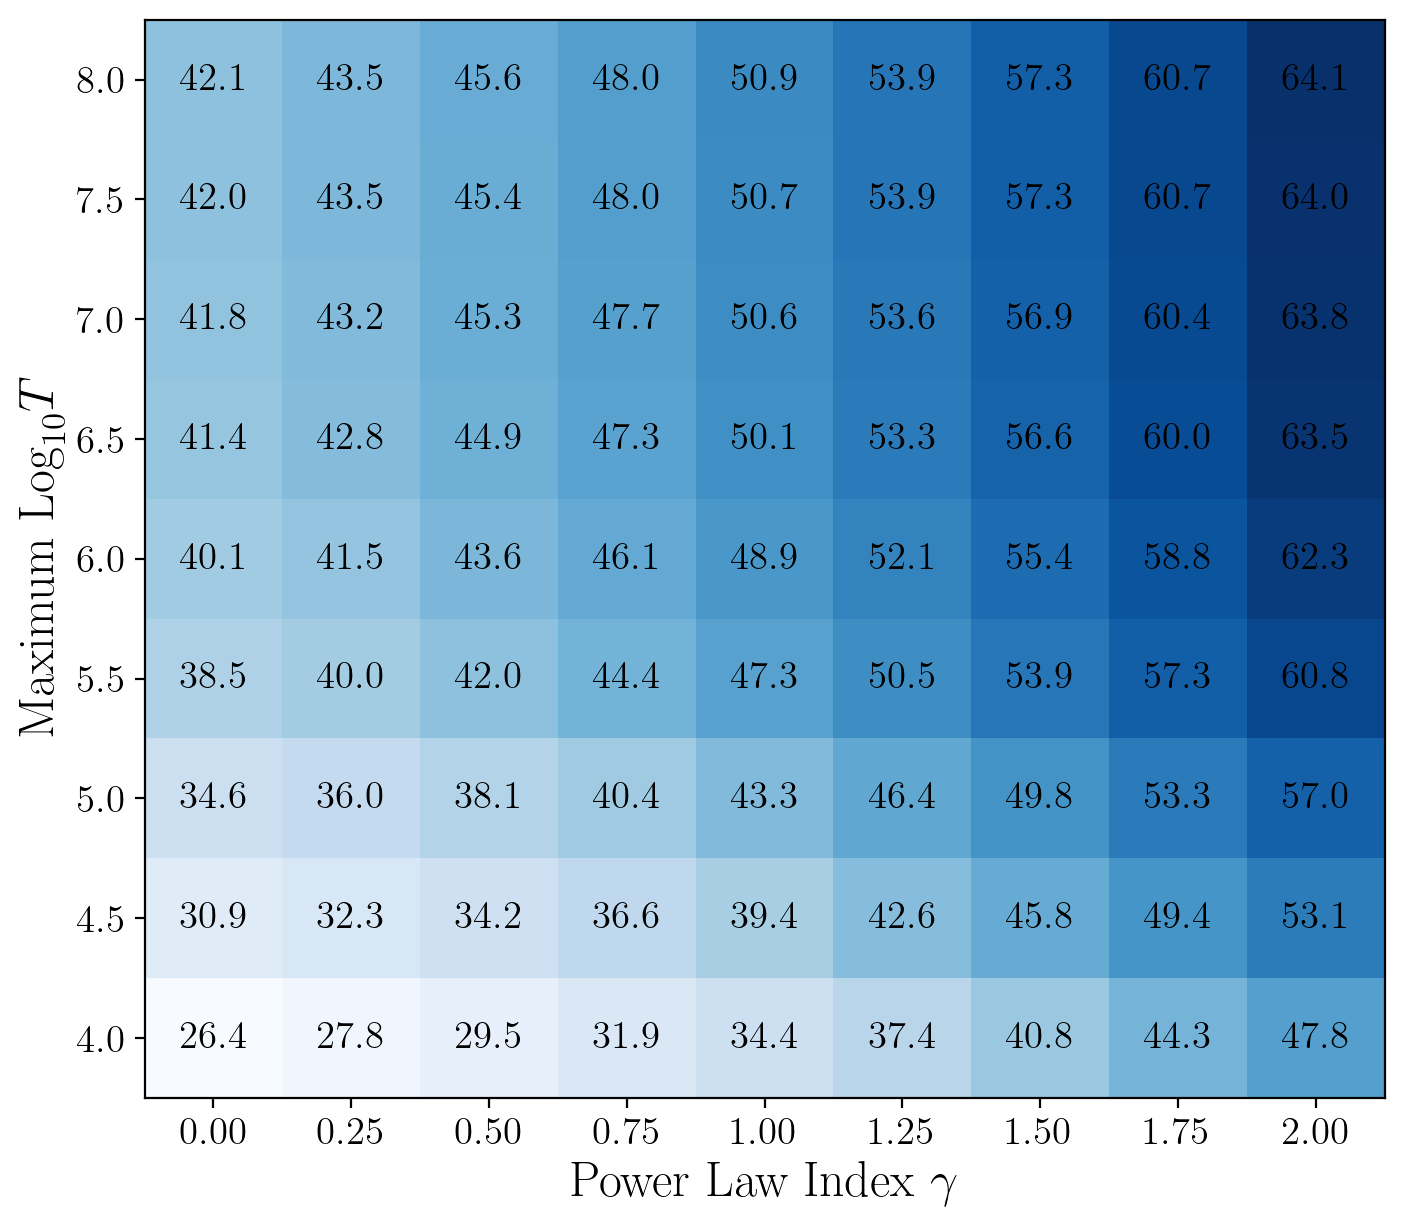

In [ ]:
def binarity_scaling(index):
    return Sampler.area_in_range_powerlaw((0.05,1), index)/Sampler.area_in_range_powerlaw((0.05,0.5), index)

new_res = np.zeros(res.shape[:-1])
for i in range(res.shape[0]):
    for j in range(res.shape[1]):
        scale = binarity_scaling(indices[j])
        new_res[i,j] = Sampler.convert_binarity(res[i,j,0], scale)
matplotlib.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(8, 7))
mesh = ax.pcolormesh(indices, cuts, new_res, cmap="Blues")

# Add text to each cell
for i in range(len(cuts)):
    for j in range(len(indices)):
        text = ax.text(indices[j], cuts[i], f'{new_res[i,j]*100:.1f}',
                      ha="center", va="center", color="black", fontsize=14)

plt.ylabel(r'Maximum $\text{Log}_{10}T$');
plt.xlabel(f'Power Law Index $\gamma$');
plt.savefig('./plots/FractionMatchingSingle.png', dpi=800, bbox_inches='tight')

#### minimum is 38.5

In [45]:
res[3,0]

array([0.22852853, 0.00576577, 0.0048048 ])

In [46]:
np.mean(res[3,0,1:])

np.float64(0.005285285285285282)

In [ ]:
def convert_binarity(fb, a):
    return a / (a + 1/fb - 1)

def reverse_convert_binarity(fb_tot, a):
    return 

In [ ]:
print(f'q<0.5: {res[3,0,0]*100:.2f}+-{np.mean(res[3,0,1:])*100:.2f}')
a = Sampler.area_in_range_powerlaw((0.05,1), 0)/Sampler.area_in_range_powerlaw((0.05,0.5), 0)
period_scaling = Sampler.area_in_range((2,4), 4, 1.3, resolution=500)/Sampler.area_in_range((1,5.5), 4, 1.3, resolution=500)

# total fb
total_mle = Sampler.convert_binarity(res[3,0,0], a)
total_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), a) - total_mle
print(f'all: {total_mle*100:.2f}+-{total_sigma*100:.2f}')

# observable range
obs_mle = Sampler.convert_binarity(res[3,0,0], period_scaling)
obs_sigma = Sampler.convert_binarity(res[3,0,0]+np.mean(res[3,0,1:]), period_scaling) - obs_mle
print(f'q<0.5, 2<T<4: {obs_mle*100:.2f}+-{obs_sigma*100:.2f}')

# all qs, 

q<0.5: 22.85+-0.53
all: 38.48+-0.71
q<0.5, 2<T<4: 13.04+-0.34
